# The RNN never learned the policy: it learned a slow drift toward the wrong certainty

*A standalone study of one finding from the FSC ↔ tinyRNN pipeline.*

## The finding, in one paragraph

On a win-stay/lose-shift (WSLS) task, we fit two minimal models to the same behavior: a
**Finite State Controller** (FSC), a small discrete memory-state controller, and the smallest
**GRU** (tinyRNN) that still explains the data. On ordinary trials they behave the same. Both
reproduce win-stay/lose-shift, and both match the data's action matrix to about 0.002. Underneath,
the two models learned different things. The FSC learned the exact rule; its transition is a lookup
on `(action, observation)`, so "you won, so stay" holds for any amount of evidence. The GRU learned
an approximation that stays correct where the data lives and fails everywhere else. The experiment
in this notebook shows that failure directly.

## The experiment: the off-manifold probe

Take a fitted RNN. Hand it the same trial repeatedly, "you chose arm A, and you won", for `k` steps
in a row. After each step, read its confidence that it will stay, meaning `P(stay)`, the softmax
action-probability at the output. WSLS makes this a flat line: win leads to stay, so after a run of
wins the model should stay with full certainty, `P(stay) = 1.0` at every `k`, forever. A model that
learned the rule can do nothing else.

It doesn't. `P(stay)` sits near 1.0 for the first 28 steps, the longest win-streak that occurs in
the 1000 training sessions, then it drifts down. Feed it enough winning evidence and its confidence
that it should stay falls, sometimes past 0.5 and out the other side. The internal state never
settles where the rule requires. It slides toward a stable fixed point that sits at the wrong
answer. The FSC, asked the same question, answers 1.0 at every `k` and never moves.

## Why this matters

The task is a one-bit rule. We gave the network 1000 sessions. The FSC captured it with two states.
The RNN, at 2, 4, or 8 hidden units, encoded "always stay" as a transient tuned to the evidence
lengths it saw in training. The behavior it produces matches the data; the rule it holds internally
does not. This is the clearest case in the project where fitting the behavior and learning the
policy come apart, and where a continuous recurrent net matches a discrete rule everywhere you can
measure while computing something different underneath.

## Roadmap

- §0 reload the committed fits, reduce everything to plain numpy.
- §1 do the two models read the same on ordinary trials? Deviation-from-data bars.
- §2 the probe: what happens to `P(stay)` under a run of wins? The hero decay curve.
- §3 what does the internal state do while confidence falls? Hidden trajectory and step-size.
- §4 why the network converges to the wrong fixed point. Fixed-point map and table.
- §5 is it just too few units? The per-size grid.
- §6 what held and what drifted across the determinism spectrum. Small-multiple grid and L1.
- §7 what this adds up to.

> **Reproducibility.** This notebook stands alone. It reloads each dataset's committed FSC and GRU
> fits from `fitted_models/<dataset>/`, re-derives one GRU step in pure numpy, and computes every
> figure live. It needs the two upstream repos already cloned on disk (`tinyRNN/`,
> `FSC-inference-MAPSO/`), the same requirement as the main pipeline. It does not rerun Section 0 of
> that pipeline, and it trains nothing.

## 0. Setup: reload the fits, reduce everything to plain numpy

One cell does the heavy lifting. It loads every dataset's committed FSC and GRU fits, pulls the
trained GRU weights into numpy, and precomputes the probe (`P(stay)` vs `k`), the hidden-state
trajectories, and the asymptotic fixed points. Everything after this runs in pure numpy and
matplotlib, so the figures re-run fast and stay easy to read.

Two mechanics come straight from the main pipeline, which documents them:
- **Import switching** (`_use_fsc_path`, `_use_tinyrnn_path`): the two repos ship modules with
  colliding names, so the code swaps `sys.path` and clears stale modules before importing from
  either side.
- **The pure-numpy GRU step** (`gru_step`): torch's `nn.GRU` returns only the hidden state, so we
  re-implement one step to expose the update, reset, and new gates. The main pipeline's §4.3 checks
  it against the library bit for bit.

In [1]:
# --- 0.1 -- imports, path switching, pure-numpy GRU, and the loaders -----------------------
import sys, os, glob, pickle, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Cross-version pandas pickle compat: the det_init model summaries were pickled with a newer
# pandas whose string arrays reduce to a 2-tuple state; teach this build to accept it. No-op
# for same-version pickles, so it is always safe to install. (Same shim as pipeline §0.)
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked
def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], np.ndarray):
        state = (state[0], state[1], {})
    return _NDArrayBacked.__setstate__(self, state)
_pd_str.StringArray.__setstate__ = _compat_string_setstate

REPO         = os.path.abspath(".")
FSC_SRC      = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING   = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path: sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:  sys.path.insert(0, FSC_SRC)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:          sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path: sys.path.insert(0, TINYRNN_ROOT)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

# Datasets, ordered LEAST -> MOST deterministic (the "determinism spectrum" of §6). Each is a
# WSLS variant; committed fits live under fitted_models/<name>/. `original` uses a legacy folder.
DATASETS      = ["rwsls_det_init", "lwsls_det_init", "random_init", "det_init", "original"]
DATASET_FILES = {
    "rwsls_det_init": "datasets/rwsls_actions_observations_det_init.npz",
    "lwsls_det_init": "datasets/lwsls_actions_observations_det_init.npz",
    "random_init":    "datasets/wsls_actions_observations_random_init.npz",
    "det_init":       "datasets/wsls_actions_observations_det_init.npz",
    "original":       "datasets/wsls_actions_observations.npz",
}
EXP_OVERRIDE = {"original": "exp_my_behavior"}   # trained before the exp_<name> convention
H_LIST       = [2, 4, 8]                          # the size sub-study, same as pipeline §4.2
KMAX         = 80                                 # probe length for the decay curves
KGRID        = np.arange(KMAX + 1)                # k = 0 (h=h0) .. KMAX

# ---- one GRU step in numpy, with the three gates exposed (torch nn.GRU equations) ----
def _sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def _softmax(z):
    z = np.asarray(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    """Returns (h', {reset r, update z, new n}). h' = (1-z)*n + z*h;  z~1 hold, z~0 overwrite."""
    H  = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r  = _sigmoid(gi[:H]    + gh[:H])
    z  = _sigmoid(gi[H:2*H] + gh[H:2*H])
    n  = np.tanh( gi[2*H:]  + r * gh[2*H:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_action_probs(h, P):   # readout: softmax(Linear(h))
    return _softmax(h @ P["lin_W"].T + P["lin_b"])

def extract_gru_params(agent):
    net = agent.model
    p = {k: v.detach().cpu().numpy() for k, v in net.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"],   "b_hh": p["bias_hh_l0"],
            "lin_W": net.lin.weight.detach().cpu().numpy(),
            "lin_b": net.lin.bias.detach().cpu().numpy(), "H": net.hidden_dim}

def encode_input(a, y, A, Y):     # one-hot(action) | one-hot(obs), as in pipeline §3.1
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0; return x

# ---- loaders -------------------------------------------------------------------------------
def load_dataset(name):
    raw = np.load(os.path.join(REPO, DATASET_FILES[name]))
    ra, ro = raw["actions"], raw["observations"]
    n_total = ra.shape[0]
    n_use = min(1000, n_total)
    idx = (np.arange(n_total) if n_use == n_total
           else np.random.default_rng(0).choice(n_total, n_use, replace=False))
    ActSpace = np.array(sorted(set(ra[idx].flatten().tolist())))
    ObsSpace = np.array(sorted(set(ro[idx].flatten().tolist())))
    a2i = {v: i for i, v in enumerate(ActSpace)}
    o2i = {v: i for i, v in enumerate(ObsSpace)}
    sessions = [{"actions":      np.array([a2i[a] for a in ra[i]], dtype=int),
                 "observations": np.array([o2i[o] for o in ro[i]], dtype=int)} for i in idx]
    win_idx  = int(np.where(ObsSpace == 1)[0][0]) if 1 in ObsSpace.tolist() else len(ObsSpace) - 1
    lose_idx = 1 - win_idx if len(ObsSpace) == 2 else 0
    return dict(name=name, ActSpace=ActSpace, ObsSpace=ObsSpace, A=len(ActSpace), Y=len(ObsSpace),
                win_idx=win_idx, lose_idx=lose_idx, sessions=sessions)

def load_rnn(name, A, Y, exp_suffix=""):
    """Restore archive->live if needed, then load GRU params at each H (best trainval loss)."""
    _use_tinyrnn_path()
    exp = EXP_OVERRIDE.get(name, f"exp_{name}") + exp_suffix
    live = f"files/saved_model/{exp}"
    arch = os.path.join(REPO, "fitted_models", name, "rnn", exp)
    cwd = os.getcwd(); os.chdir("tinyRNN")
    try:
        if os.path.isdir(arch) and not os.path.isdir(live): shutil.copytree(arch, live)
        if not os.path.isdir(live): return {}
        from agents import Agent
        from analyzing_experiments.analyzing_perf import select_final_rnn_perf
        _, summary, _ = select_final_rnn_perf(exp, return_dim_est=True, verbose=False)
        out = {}
        for H in H_LIST:
            rows = summary[summary["hidden_dim"] == H].sort_values("trainval_loss")
            if len(rows) == 0: continue
            cfg = {"agent_type": "RNN", "rnn_type": "GRU", "input_dim": A + Y, "hidden_dim": H,
                   "output_dim": A, "device": "cpu", "output_h0": True, "trainable_h0": False,
                   "readout_FC": True, "one_hot": False, "seed": 0}
            ag = Agent("RNN", config=cfg); ag.load(str(rows.iloc[0]["model_path"]))
            out[H] = extract_gru_params(ag)
        return out
    finally:
        os.chdir(cwd)

def load_fsc(name):
    _use_fsc_path()
    paths = glob.glob(os.path.join(REPO, f"fitted_models/{name}/fsc/best_fsc_M*.pkl"))
    if not paths: return None
    m = int(paths[0].split("_M")[-1].split(".pkl")[0])
    with open(paths[0], "rb") as f: fsc = pickle.load(f)
    fsc.set_mode("generation")
    return dict(M=m, rho=np.asarray(fsc.get_rho()),
                TMat=np.asarray(fsc.get_TMat()), pol=np.asarray(fsc.get_action_policy()))

print("Setup 0.1 OK: helpers defined.")

Setup 0.1 OK: helpers defined.


In [2]:
# --- 0.2 -- The probe + fixed-point analysis, run once for every dataset -------------------
# For each dataset we cache, per hidden size H and per starting arm a0:
#   * pstay[k]    -- P(stay on a0) after k consecutive (chose a0, won) trials, from h0=0
#   * hidden[k]   -- the hidden state at each k (for §3)
#   * gates[k]    -- update/reset/new gate vectors at each step (cached for reference)
#   * fp_pstay    -- P(stay) at the ASYMPTOTIC fixed point (k -> infinity)
#   * spec_radius -- spectral radius of the map's Jacobian at that fixed point (<1 => stable)
# and the FSC's own P(stay) vs k (a discrete-state belief recursion). Also the empirical +
# model win-stay / lose-shift rates for the on-manifold check in §1.

def rnn_probe(P, a0, y_idx, A, Y, kmax=KMAX):
    x = encode_input(a0, y_idx, A, Y)
    h = np.zeros(P["H"])
    hidden = [h.copy()]; gates = []; pstay = [rnn_action_probs(h, P)[a0]]
    for _ in range(kmax):
        h, g = gru_step(h, x, P); hidden.append(h.copy()); gates.append(g)
        pstay.append(rnn_action_probs(h, P)[a0])
    return dict(pstay=np.array(pstay), hidden=np.array(hidden), gates=gates)

def rnn_fixed_point(P, a0, y_idx, A, Y, n_iter=4000, eps=1e-6):
    x = encode_input(a0, y_idx, A, Y)
    h = np.zeros(P["H"])
    for _ in range(n_iter): h, _ = gru_step(h, x, P)
    J = np.zeros((P["H"], P["H"]))
    for j in range(P["H"]):
        hp = h.copy(); hp[j] += eps
        hpn, _ = gru_step(hp, x, P); J[:, j] = (hpn - h) / eps
    return dict(pstay=float(rnn_action_probs(h, P)[a0]),
                spec_radius=float(np.max(np.abs(np.linalg.eigvals(J)))))

def fsc_probe(FS, a0, y_idx, kmax=KMAX):
    b = FS["rho"].copy(); pstay = [float((b @ FS["pol"])[a0])]
    for _ in range(kmax):
        bn = b @ FS["TMat"][y_idx, :, :, a0]; s = bn.sum()
        b = bn / s if s > 0 else b
        pstay.append(float((b @ FS["pol"])[a0]))
    return np.array(pstay)

def empirical_rates(sessions, win_idx, lose_idx, A):
    """P(stay|win) and P(shift|lose) by straight counting on the behavior."""
    stay_w = shift_l = 0; n_w = n_l = 0
    for s in sessions:
        a, o = s["actions"], s["observations"]
        for t in range(1, len(a)):
            if o[t-1] == win_idx:
                n_w += 1; stay_w  += (a[t] == a[t-1])
            elif o[t-1] == lose_idx:
                n_l += 1; shift_l += (a[t] != a[t-1])
    return (stay_w / n_w if n_w else np.nan), (shift_l / n_l if n_l else np.nan)

def model_rates(step_probs, sessions, win_idx, lose_idx, A):
    """Teacher-forced replay: average model P(stay|win) and P(shift|lose) over the real
    histories. `step_probs(state)->(probs, next_state)` abstracts FSC vs RNN."""
    stay_w = shift_l = 0.0; n_w = n_l = 0
    for s in sessions:
        a, o = s["actions"], s["observations"]
        st = None
        for t in range(len(a)):
            p, st = step_probs(st, a, o, t)
            if t >= 1:
                if o[t-1] == win_idx:
                    n_w += 1; stay_w  += p[a[t-1]]
                elif o[t-1] == lose_idx:
                    n_l += 1; shift_l += 1 - p[a[t-1]]
    return (stay_w / n_w if n_w else np.nan), (shift_l / n_l if n_l else np.nan)

DATA = {}
for name in DATASETS:
    d = load_dataset(name)
    A, Y, wi, li = d["A"], d["Y"], d["win_idx"], d["lose_idx"]
    d["rnn"] = load_rnn(name, A, Y)
    d["fsc"] = load_fsc(name)

    # win-streak lengths actually present in the data (defines the "in-data" region)
    streaks = []
    for s in d["sessions"]:
        run = 0
        for v in s["observations"]:
            run = run + 1 if v == wi else 0
            streaks.append(run)
    d["streaks"] = np.array(streaks)
    d["max_streak"] = int(d["streaks"].max())

    # off-manifold probe + fixed points, per H per arm
    d["probe"] = {H: {a0: rnn_probe(P, a0, wi, A, Y)          for a0 in range(A)} for H, P in d["rnn"].items()}
    d["fp"]    = {H: {a0: rnn_fixed_point(P, a0, wi, A, Y)     for a0 in range(A)} for H, P in d["rnn"].items()}
    d["fsc_probe"] = ({a0: fsc_probe(d["fsc"], a0, wi) for a0 in range(A)} if d["fsc"] else {})

    # on-manifold rates: data, FSC, each RNN
    d["rate_data"] = empirical_rates(d["sessions"], wi, li, A)
    if d["fsc"]:
        FS = d["fsc"]
        def fsc_step(st, a, o, t, FS=FS, A=A):
            b = FS["rho"].copy() if st is None else st
            p = b @ FS["pol"]
            bn = b @ FS["TMat"][o[t], :, :, a[t]]; s = bn.sum()
            return p, (bn / s if s > 0 else b)
        d["rate_fsc"] = model_rates(fsc_step, d["sessions"], wi, li, A)
    d["rate_rnn"] = {}
    for H, P in d["rnn"].items():
        def rnn_step(st, a, o, t, P=P, A=A, Y=Y):
            h = np.zeros(P["H"]) if st is None else st
            p = rnn_action_probs(h, P)
            hn, _ = gru_step(h, encode_input(a[t], o[t], A, Y), P)
            return p, hn
        d["rate_rnn"][H] = model_rates(rnn_step, d["sessions"], wi, li, A)

    DATA[name] = d
    print(f"{name:>15s}: A={A} Y={Y}  RNN Hs={list(d['rnn'])}  "
          f"FSC M={d['fsc']['M'] if d['fsc'] else '--'}  max win-streak={d['max_streak']}")

_use_fsc_path()
print("\nSetup 0.2 OK: probe and fixed points cached for all datasets.")

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}



  0%|          | 0/8 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 888.08it/s]

 rwsls_det_init: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=18
Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}



  0%|          | 0/8 [00:00<?, ?it/s]

...


100%|██████████| 8/8 [00:00<00:00, 1214.95it/s]

       det_init: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=33
Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}



  0%|          | 0/8 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 1077.60it/s]

       original: A=2 Y=2  RNN Hs=[2, 4, 8]  FSC M=2  max win-streak=28

Setup 0.2 OK: probe and fixed points cached for all datasets.


In [3]:
# --- 0.3 -- plot style + a shared color scheme (colorblind-safe categorical slots) ---------
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
})
C_FSC   = "#111111"   # near-black -- the FSC is the authoritative reference, not a series hue
C_ARM0  = "#2a78d6"   # blue  -- RNN, arm index 0
C_ARM1  = "#eb6834"   # orange-- RNN, arm index 1
C_H     = {2: "#2a78d6", 4: "#eb6834", 8: "#1baf7a"}          # fixed order for the size study
C_ARM   = {0: C_ARM0, 1: C_ARM1}
C_RULE  = "0.35"      # dashed "should be certain" reference
C_TRUE  = "#4a3aa7"   # violet -- the true (possibly non-1) rate on stochastic data
SHADE   = "#8a8a86"

def shade_indata(ax, max_streak, label=True):
    ax.axvspan(0, max_streak, color=SHADE, alpha=0.13, lw=0, zorder=0)
    if label:
        ax.text(max_streak, 0.02, f" longest streak\n in data (k={max_streak})",
                fontsize=7.5, color="0.4", ha="left", va="bottom",
                transform=ax.get_xaxis_transform())

def arm_label(d, a0):
    return f"arm {d['ActSpace'][a0]}"

HERO = "random_init"   # the worked example throughout §2-§4 (this project's primary dataset)
print(f"Style ready. Hero dataset = {HERO!r}.")

Style ready. Hero dataset = 'random_init'.


## 1. On ordinary trials, the two models are indistinguishable

On the trials the data contains, the FSC and the RNN behave the same. Two numbers define WSLS,
`P(stay | previous win)` and `P(shift | previous loss)`. For every dataset, the chart below
compares each model's rates against the real data, plotted as the absolute deviation from the data
on a log scale, so exact matches fall to the floor.

Both models sit within about 0.002 of the real behavior, and the FSC often lands exactly on 0, a
hard 0/1 policy. Behavior on the data's own distribution cannot separate the two models; §2 onward
does. `rwsls_det_init` is the stochastic control: its true rule is genuinely probabilistic, so a
match there means matching a rate near 0.67 rather than hitting 1.0.

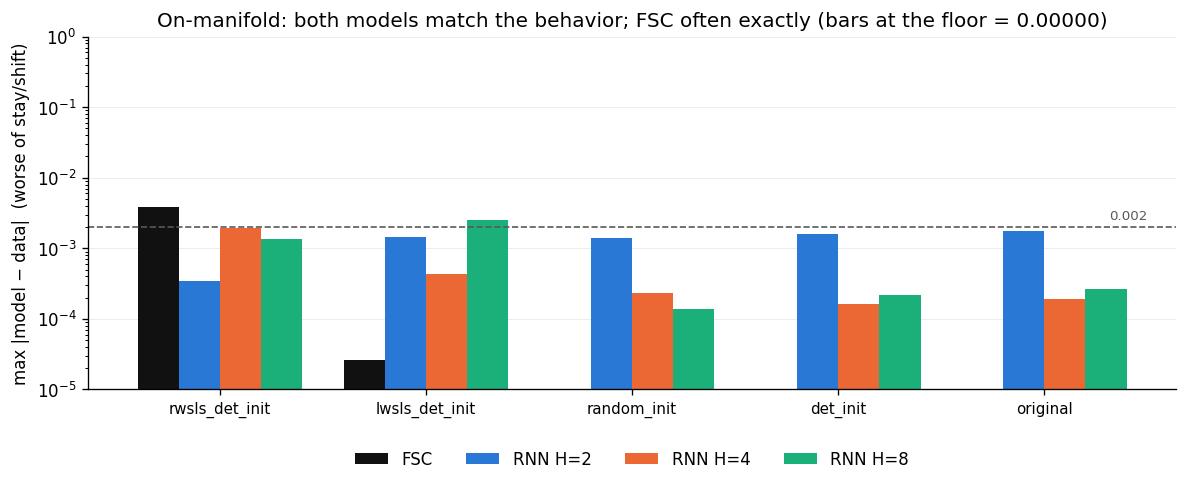

Win-stay / lose-shift rates  (real  |  FSC  |  RNN by H):

  rwsls_det_init
     P(stay|win) : data=0.6653  FSC=0.6691  H2=0.6655  H4=0.6656  H8=0.6645
     P(shift|lose): data=0.2008  FSC=0.2036  H2=0.2011  H4=0.2027  H8=0.2021

  lwsls_det_init
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9992  H4=0.9997  H8=0.9998
     P(shift|lose): data=0.2004  FSC=0.2004  H2=0.1989  H4=0.2000  H8=0.1978

  random_init
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9995  H4=0.9998  H8=0.9999
     P(shift|lose): data=1.0000  FSC=1.0000  H2=0.9986  H4=0.9998  H8=0.9999

  det_init
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9995  H4=0.9999  H8=0.9999
     P(shift|lose): data=1.0000  FSC=1.0000  H2=0.9984  H4=0.9998  H8=0.9998

  original
     P(stay|win) : data=1.0000  FSC=1.0000  H2=0.9993  H4=0.9999  H8=0.9999
     P(shift|lose): data=1.0000  FSC=1.0000  H2=0.9982  H4=0.9998  H8=0.9997


In [4]:
# --- 1 -- how far each model's win-stay / lose-shift rate sits from the real data ----------
rows = []
for name in DATASETS:
    d = DATA[name]
    sw_d, sl_d = d["rate_data"]
    if d.get("rate_fsc"):
        rows.append((name, "FSC", abs(d["rate_fsc"][0]-sw_d), abs(d["rate_fsc"][1]-sl_d)))
    for H in d["rnn"]:
        rows.append((name, f"RNN H={H}", abs(d["rate_rnn"][H][0]-sw_d), abs(d["rate_rnn"][H][1]-sl_d)))
dev = pd.DataFrame(rows, columns=["dataset", "model", "|Δ P(stay|win)|", "|Δ P(shift|lose)|"])

fig, ax = plt.subplots(figsize=(10, 4.2))
models = ["FSC", "RNN H=2", "RNN H=4", "RNN H=8"]
mcolor = {"FSC": C_FSC, "RNN H=2": C_H[2], "RNN H=4": C_H[4], "RNN H=8": C_H[8]}
x = np.arange(len(DATASETS)); w = 0.2; FLOOR = 1e-5
for i, m in enumerate(models):
    vals = []
    for name in DATASETS:
        sub = dev[(dev["dataset"] == name) & (dev["model"] == m)]
        # worst of the two rates, floored so exact-zero still draws a visible stub
        vals.append(max(sub[["|Δ P(stay|win)|", "|Δ P(shift|lose)|"]].max(axis=1).max(), FLOOR)
                    if len(sub) else FLOOR)
    ax.bar(x + (i - 1.5) * w, vals, w, label=m, color=mcolor[m], edgecolor="none")
ax.set_yscale("log"); ax.set_ylim(FLOOR, 1)
ax.axhline(0.002, color=C_RULE, ls="--", lw=1)
ax.text(len(DATASETS)-0.5, 0.0023, "0.002", fontsize=8, color=C_RULE, va="bottom", ha="right")
ax.set_xticks(x); ax.set_xticklabels(DATASETS, fontsize=9)
ax.set_ylabel("max |model − data|  (worse of stay/shift)")
ax.set_title("On-manifold: both models match the behavior; FSC often exactly (bars at the floor = 0.00000)")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.13))
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print("Win-stay / lose-shift rates  (real  |  FSC  |  RNN by H):")
for name in DATASETS:
    d = DATA[name]
    print(f"\n  {name}")
    print(f"     P(stay|win) : data={d['rate_data'][0]:.4f}"
          + (f"  FSC={d['rate_fsc'][0]:.4f}" if d.get('rate_fsc') else "")
          + "".join(f"  H{H}={d['rate_rnn'][H][0]:.4f}" for H in d["rnn"]))
    print(f"     P(shift|lose): data={d['rate_data'][1]:.4f}"
          + (f"  FSC={d['rate_fsc'][1]:.4f}" if d.get('rate_fsc') else "")
          + "".join(f"  H{H}={d['rate_rnn'][H][1]:.4f}" for H in d["rnn"]))

## 2. The probe: hand it a run of wins and watch its confidence fall

Take the hero dataset (`random_init`) and its smallest RNN, `H=2`. Drive it from a blank state with
the same trial repeated, chose arm A and won, and after each of `k` steps read `P(stay on A)`. WSLS
makes this a flat line at 1.0: you keep winning, you keep staying, with growing certainty. The FSC
(black) holds that line. The RNN slides off it.

The shaded band marks the longest win-streak anywhere in the 1000 training sessions. Inside the
band the RNN holds near 1.0, the region where training pinned it down. Past the band its confidence
slides, and the two arms diverge: one stays at 1.0, the other collapses. Section 5 shows the
collapsing arm is a training coin-toss rather than a property of the task.

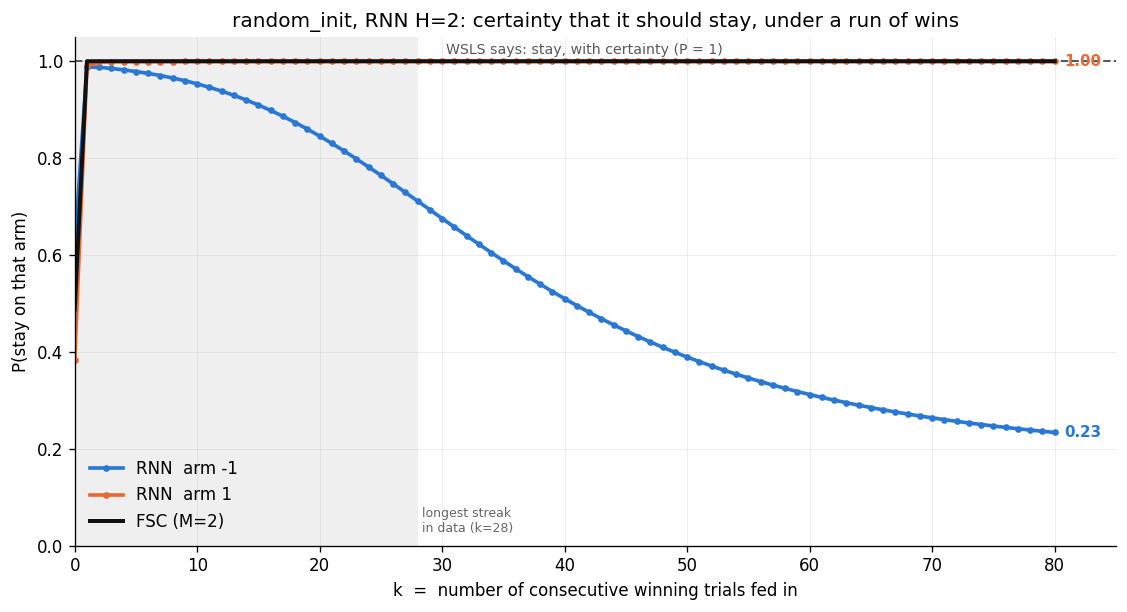

P(stay) at k=1 vs k=80   (should be 1.000 at both, per WSLS):
    arm -1:  0.988  ->  0.234   <-- collapses
     arm 1:  0.990  ->  1.000   (holds)
   FSC    :  1.000  ->  1.000   (flat, a lookup table)


In [5]:
# --- 2 -- the hero decay curve: P(stay) vs k on random_init, H=2, both arms + FSC ----------
d = DATA[HERO]; H = 2; A = d["A"]
fig, ax = plt.subplots(figsize=(9.5, 5.2))
shade_indata(ax, d["max_streak"])
ax.axhline(1.0, color=C_RULE, ls="--", lw=1.2)
ax.text(KMAX * 0.52, 1.008, "WSLS says: stay, with certainty (P = 1)", fontsize=8.5,
        color=C_RULE, ha="center", va="bottom")

for a0 in range(A):
    ax.plot(KGRID, d["probe"][H][a0]["pstay"], color=C_ARM[a0], lw=2.2,
            marker="o", ms=3, label=f"RNN  {arm_label(d, a0)}")
    ax.annotate(f"{d['probe'][H][a0]['pstay'][-1]:.2f}", (KMAX, d["probe"][H][a0]["pstay"][-1]),
                xytext=(6, 0), textcoords="offset points", color=C_ARM[a0], fontsize=9,
                va="center", fontweight="bold")
if d["fsc_probe"]:
    ax.plot(KGRID, d["fsc_probe"][0], color=C_FSC, lw=2.4, label=f"FSC (M={d['fsc']['M']})")

ax.set_xlim(0, KMAX + 5); ax.set_ylim(0, 1.05)
ax.set_xlabel("k  =  number of consecutive winning trials fed in")
ax.set_ylabel("P(stay on that arm)")
ax.set_title(f"{HERO}, RNN H={H}: certainty that it should stay, under a run of wins")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

print(f"P(stay) at k=1 vs k={KMAX}   (should be 1.000 at both, per WSLS):")
for a0 in range(A):
    p = d["probe"][H][a0]["pstay"]
    print(f"   {arm_label(d, a0):>7s}:  {p[1]:.3f}  ->  {p[KMAX]:.3f}"
          + ("   <-- collapses" if p[KMAX] < 0.9 else "   (holds)"))
if d["fsc_probe"]:
    print(f"   FSC    :  {d['fsc_probe'][0][1]:.3f}  ->  {d['fsc_probe'][0][KMAX]:.3f}   (flat, a lookup table)")

## 3. What the internal state does while confidence falls

`P(stay)` reads out the hidden state `h`, so look at `h` directly. The left panel traces each
hidden unit over `k` for both arms. The right panel carries the result: the step size, the norm of
`h(k+1) - h(k)`, meaning how far the state still moves each time it receives the same input.

A model that learned "always stay" would drive `h` to a fixed point, a state the repeated input
leaves unchanged, so the step size would crash to zero and stay there. The holding arm does that;
its curve drops off the bottom of the log axis. The collapsing arm keeps moving for tens of steps
and drags the readout down the whole way. The FSC's belief (dotted) reaches its fixed point after
one step; a single lookup finishes it.

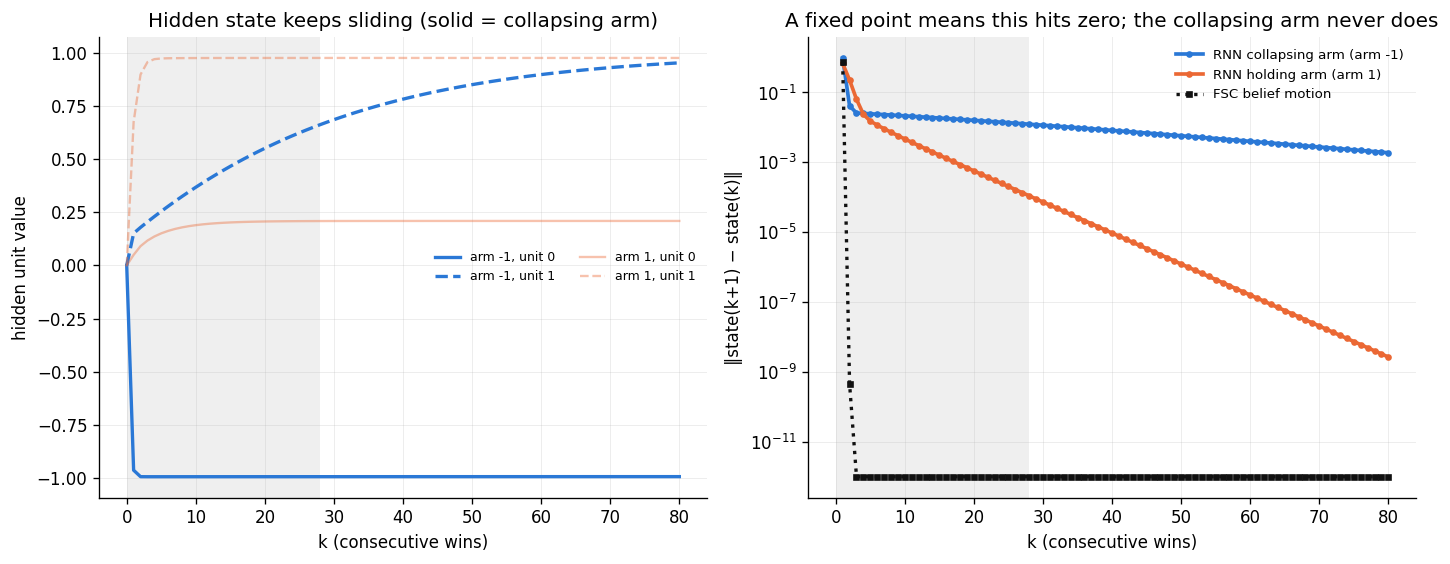

Holding arm  = arm 1  (fixed-point P(stay) = 1.000)
Collapsing arm = arm -1  (fixed-point P(stay) = 0.178)


In [6]:
# --- 3 -- hidden-state trajectory (left) and per-step motion (right) -----------------------
d = DATA[HERO]; H = 2; A = d["A"]
# identify which arm holds and which collapses, from the cached fixed points
fp = d["fp"][H]
hold_arm  = max(range(A), key=lambda a: fp[a]["pstay"])
drift_arm = min(range(A), key=lambda a: fp[a]["pstay"])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.8))

# left: hidden components vs k, collapsing arm solid, holding arm faded
for a0, style in [(drift_arm, dict(lw=2.0, alpha=1.0)), (hold_arm, dict(lw=1.4, alpha=0.4))]:
    hid = d["probe"][H][a0]["hidden"]
    for u in range(H):
        axL.plot(KGRID, hid[:, u], color=C_ARM[a0], ls=["-", "--"][u % 2],
                 label=(f"{arm_label(d, a0)}, unit {u}"), **style)
shade_indata(axL, d["max_streak"], label=False)
axL.set_xlabel("k (consecutive wins)"); axL.set_ylabel("hidden unit value")
axL.set_title("Hidden state keeps sliding (solid = collapsing arm)")
axL.legend(fontsize=7.5, ncol=2, loc="best")

# right: step size ||dh|| vs k, log scale
for a0, lbl in [(drift_arm, "collapsing arm"), (hold_arm, "holding arm")]:
    hid = d["probe"][H][a0]["hidden"]
    dh = np.linalg.norm(np.diff(hid, axis=0), axis=1)
    axR.semilogy(KGRID[1:], np.clip(dh, 1e-12, None), color=C_ARM[a0], lw=2.2,
                 marker="o", ms=3, label=f"RNN {lbl} ({arm_label(d, a0)})")
if d["fsc_probe"]:
    # FSC belief motion: change in belief vector per step
    b = d["fsc"]["rho"].copy(); moves = []
    for _ in range(KMAX):
        bn = b @ d["fsc"]["TMat"][d["win_idx"], :, :, drift_arm]; s = bn.sum()
        bn = bn / s if s > 0 else b; moves.append(np.linalg.norm(bn - b)); b = bn
    axR.semilogy(KGRID[1:], np.clip(moves, 1e-12, None), color=C_FSC, lw=2.0, ls=":",
                 marker="s", ms=3, label="FSC belief motion")
shade_indata(axR, d["max_streak"], label=False)
axR.set_xlabel("k (consecutive wins)"); axR.set_ylabel("‖state(k+1) − state(k)‖")
axR.set_title("A fixed point means this hits zero; the collapsing arm never does")
axR.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()

print(f"Holding arm  = {arm_label(d, hold_arm)}  (fixed-point P(stay) = {fp[hold_arm]['pstay']:.3f})")
print(f"Collapsing arm = {arm_label(d, drift_arm)}  (fixed-point P(stay) = {fp[drift_arm]['pstay']:.3f})")

## 4. Why the network converges to the wrong fixed point

The slide in §3 is a contraction. Under the constant input the GRU map `h ↦ h'` has one stable
fixed point `h*`, and the state is pulled into it. Two facts make that fixed point the cause, and
both hold across every dataset, size, and arm.

First, it converges. Iterate the same "you won" input to convergence and linearize there: the
Jacobian's spectral radius stays below 1 everywhere. The network settles rather than oscillating or
diverging. A short algebraic note on where it settles: at a fixed point, `h' = (1-z)·n + z·h` forces
`h* = n*`, the candidate state. The input-driven proposal sets the resting state, and nothing
latches the readout at 1.0. The resting readout equals `softmax(Linear(n*))`, whatever that comes
out to.

Second, on the collapsing arms that resting readout is the wrong certainty, with `P(stay)` fixed
points near 0.1 to 0.2 in place of 1.0. The spectral radius sits just under 1 (about 0.96 to 0.99),
so the pull is slow. Across the win-streaks of at most 28 steps the data contains, the readout
barely moves, which is why training never charged the network for it. Past those streak lengths the
same slow contraction continues, all the way to the wrong answer.

The RNN converged on a different rule: after a long run of wins, drift toward unsure or flip
outright. The chart below places every configuration's fixed point on the `P(stay)` axis, and the
table gives the numbers. The FSC can land only on 1.0, since its winning memory-state maps to
itself, a true fixed point at the exact policy value.

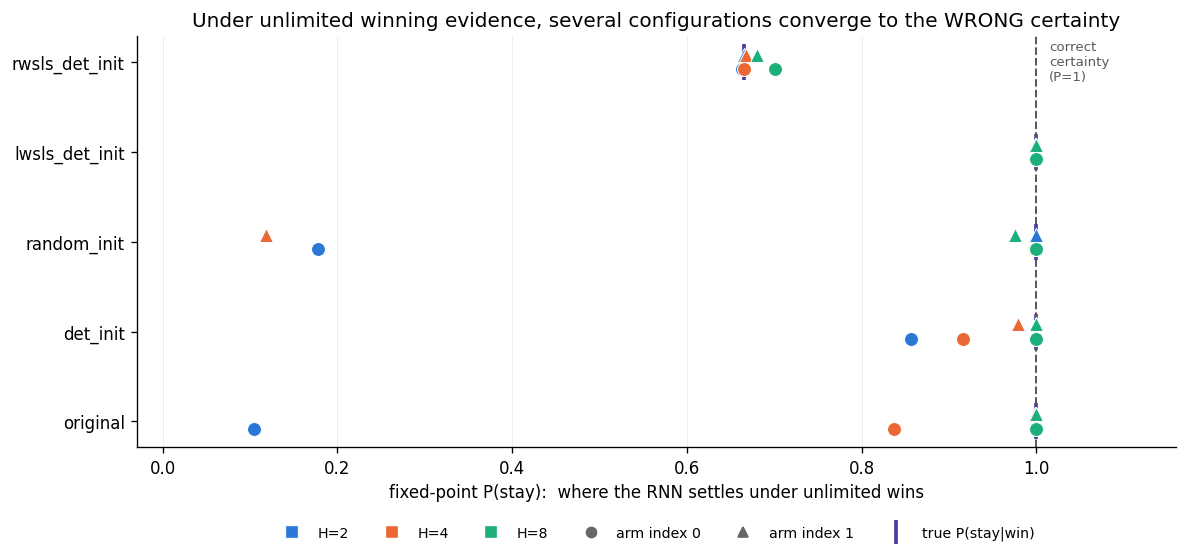

In [7]:
# --- 4a -- where UNLIMITED winning evidence actually takes each RNN (the fixed points) ------
# One row per dataset; each point is one (H, arm) configuration placed at its fixed-point P(stay).
# A model that learned WSLS would put every point on the "correct certainty" line. Marker shape =
# arm, color = hidden size. The violet tick is the dataset's TRUE P(stay|win) (=1.0 when the rule
# is deterministic, ~0.67 on the stochastic control) -- the value a correct model should converge to.
fig, ax = plt.subplots(figsize=(10, 4.8))
ymap = {name: i for i, name in enumerate(reversed(DATASETS))}   # most-deterministic on top
marker = {0: "o", 1: "^"}
for name in DATASETS:
    d = DATA[name]; y = ymap[name]
    for H in d["rnn"]:
        for a0 in range(d["A"]):
            fpv = d["fp"][H][a0]["pstay"]
            ax.scatter(fpv, y + (a0 - 0.5) * 0.16, s=70, color=C_H[H], marker=marker[a0],
                       edgecolor="white", linewidth=0.6, zorder=3)
    ax.plot([d["rate_data"][0]], [y], marker="|", ms=22, color=C_TRUE, mew=2.2, zorder=2)
ax.axvline(1.0, color=C_RULE, ls="--", lw=1.2)
ax.text(1.015, len(DATASETS) - 1, "correct\ncertainty\n(P=1)",
        fontsize=8, color=C_RULE, ha="left", va="center")
ax.set_yticks(list(ymap.values())); ax.set_yticklabels(list(ymap.keys()))
ax.set_xlim(-0.03, 1.16); ax.set_xlabel("fixed-point P(stay):  where the RNN settles under unlimited wins")
ax.set_title("Under unlimited winning evidence, several configurations converge to the WRONG certainty")
# legends: color=H, shape=arm, tick=true rate
from matplotlib.lines import Line2D
h_handles = [Line2D([], [], marker="s", ls="", color=C_H[H], label=f"H={H}") for H in H_LIST]
a_handles = [Line2D([], [], marker=marker[a], ls="", color="0.4", label=f"arm index {a}") for a in (0, 1)]
t_handle  = [Line2D([], [], marker="|", ls="", color=C_TRUE, mew=2.2, ms=14, label="true P(stay|win)")]
ax.legend(handles=h_handles + a_handles + t_handle, ncol=6, loc="upper center",
          bbox_to_anchor=(0.5, -0.16), fontsize=8.5)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [8]:
# --- 4b -- the fixed-point table: where unlimited winning evidence actually takes each RNN --
rows = []
for name in DATASETS:
    d = DATA[name]
    for H in d["rnn"]:
        for a0 in range(d["A"]):
            fp = d["fp"][H][a0]
            rows.append({
                "dataset": name, "H": H, "arm": str(d["ActSpace"][a0]),
                "P(stay) k=1":   round(float(d["probe"][H][a0]["pstay"][1]), 3),
                "P(stay) k=80":  round(float(d["probe"][H][a0]["pstay"][KMAX]), 3),
                "P(stay) fixed-pt": round(fp["pstay"], 3),
                "spectral radius":  round(fp["spec_radius"], 3),
                "verdict": ("correctly certain" if fp["pstay"] > 0.95 else
                            "drifts to WRONG certainty" if fp["pstay"] < 0.55 else
                            "partial drift"),
            })
fp_table = pd.DataFrame(rows)
# show the hero + the clearest failures first
print("Fixed-point analysis: the state each RNN settles into under UNLIMITED winning evidence.")
print("(WSLS requires P(stay) fixed-point = 1.000 on every deterministic dataset.)\n")
fp_table

Fixed-point analysis: the state each RNN settles into under UNLIMITED winning evidence.
(WSLS requires P(stay) fixed-point = 1.000 on every deterministic dataset.)



,dataset,H,arm,P(stay) k=1,P(stay) k=80,P(stay) fixed-pt,spectral radius,verdict
0,rwsls_det_init,2,-1,0.671,0.663,0.663,0.070,partial drift
1,rwsls_det_init,2,1,0.674,0.666,0.666,0.053,partial drift
2,rwsls_det_init,4,-1,0.692,0.665,0.665,0.217,partial drift
3,rwsls_det_init,4,1,0.574,0.668,0.668,0.226,partial drift
4,rwsls_det_init,8,-1,0.657,0.701,0.701,0.840,partial drift
5,rwsls_det_init,8,1,0.643,0.680,0.680,0.569,partial drift
6,lwsls_det_init,2,-1,1.000,1.000,1.000,0.303,correctly certain
7,lwsls_det_init,2,1,0.997,0.999,0.999,0.082,correctly certain
8,lwsls_det_init,4,-1,0.998,1.000,1.000,0.554,correctly certain
9,lwsls_det_init,4,1,0.999,0.999,0.999,0.620,correctly certain


## 5. Adding hidden units does not fix the drift

The natural objection says `H=2` is too small. The probe rules that out. Below it runs on
`random_init` at `H=2, 4, 8`. Every size reproduces WSLS on the data manifold (§1), and every size
breaks on a different arm: `H=2` collapses one arm, `H=4` the other, with the choice set by random
initialization. Extra units relocate the crack to a different arm and leave the drift in place. The
main pipeline's participation-ratio analysis reaches the same conclusion from another angle: these
RNNs use only about 1.7 to 2.8 effective dimensions regardless of how many units they hold.

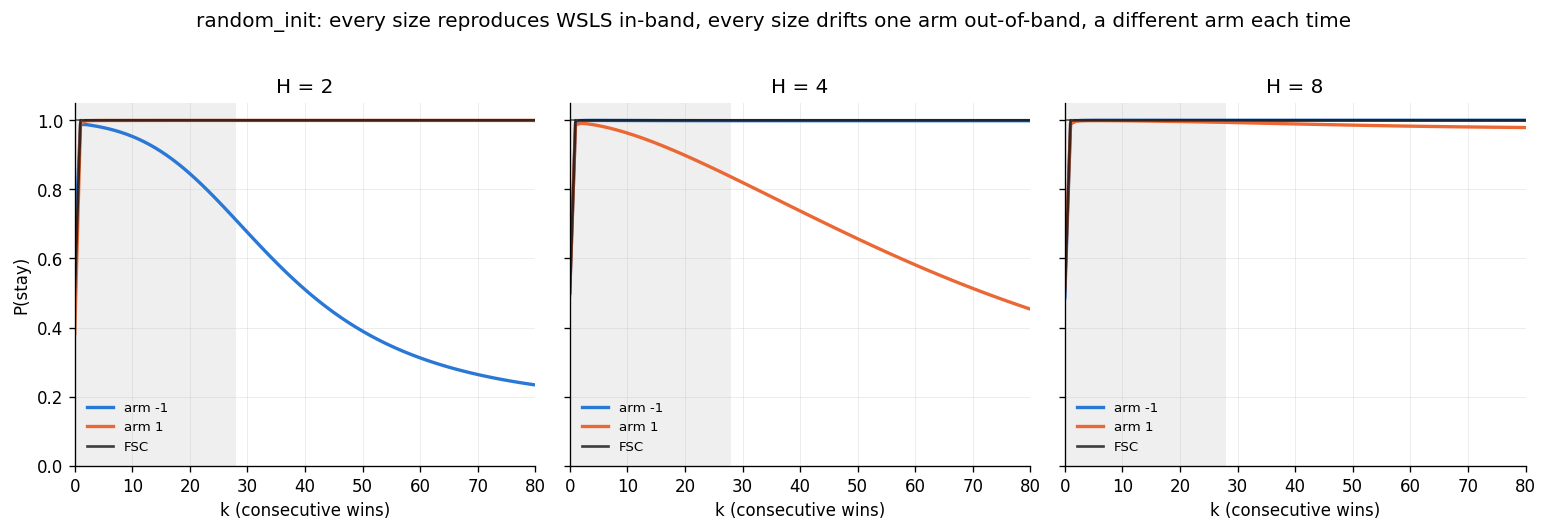

Fixed-point P(stay) per size and arm (which arm stays certain flips with size):
   H=2: arm -1=0.178   arm 1=1.000
   H=4: arm -1=0.999   arm 1=0.119
   H=8: arm -1=1.000   arm 1=0.975


In [9]:
# --- 5 -- same probe, three sizes: each holds one arm and drifts the other -----------------
d = DATA[HERO]; A = d["A"]
fig, axes = plt.subplots(1, len(H_LIST), figsize=(13, 4.3), sharey=True)
for ax, H in zip(axes, H_LIST):
    if H not in d["probe"]:
        ax.set_visible(False); continue
    shade_indata(ax, d["max_streak"], label=False)
    ax.axhline(1.0, color=C_RULE, ls="--", lw=1)
    for a0 in range(A):
        ax.plot(KGRID, d["probe"][H][a0]["pstay"], color=C_ARM[a0], lw=2.0,
                label=arm_label(d, a0))
    if d["fsc_probe"]:
        ax.plot(KGRID, d["fsc_probe"][0], color=C_FSC, lw=1.6, alpha=0.8, label="FSC")
    ax.set_xlim(0, KMAX); ax.set_ylim(0, 1.05)
    ax.set_title(f"H = {H}"); ax.set_xlabel("k (consecutive wins)")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("P(stay)")
fig.suptitle(f"{HERO}: every size reproduces WSLS in-band, every size drifts one arm out-of-band, "
             "a different arm each time", y=1.02)
plt.tight_layout(); plt.show()

print("Fixed-point P(stay) per size and arm (which arm stays certain flips with size):")
for H in d["rnn"]:
    print(f"   H={H}: " + "   ".join(f"{arm_label(d, a0)}={d['fp'][H][a0]['pstay']:.3f}" for a0 in range(A)))

## 6. The whole spectrum: what held and what drifted

The finding varies across datasets, which is worth showing plainly. The probe below runs on all
five, ordered from the least deterministic rule (top-left) to the most (bottom). Each panel draws
the worst-drifting arm at each size, the FSC, and a dashed line at the true `P(stay|win)` the rule
implies.

- `rwsls_det_init` is the honest control. Its rule is genuinely stochastic, `P(stay|win)` near 0.67.
  The RNN's curve flattening below 1.0 is the correct behavior here, and it reaches a real fixed
  point at that value. A stable fixed point is fine when the true rule is stochastic. The failure
  appears on the deterministic datasets, where the fixed point lands at the wrong value.
- `lwsls_det_init` has a deterministic win side and holds well.
- `random_init`, `det_init`, and `original` all have a fully deterministic `P(stay|win)=1.0`, and
  all show at least one arm or size drifting off it once the input leaves the data.

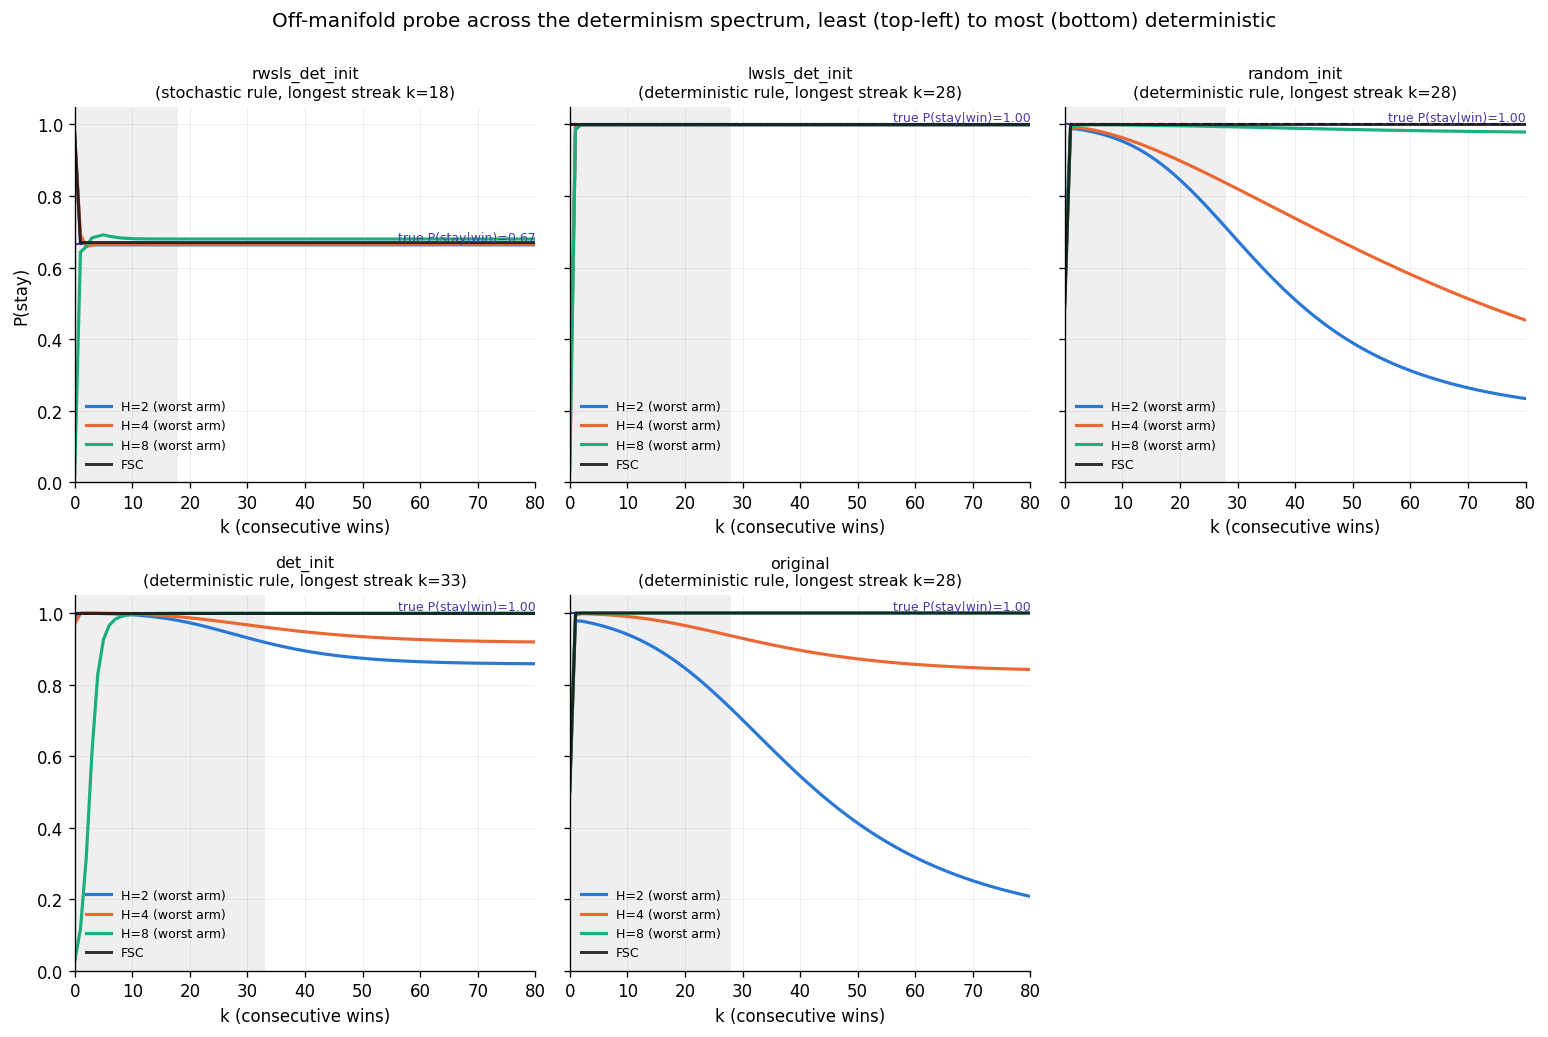

In [10]:
# --- 6 -- small-multiple grid: the probe across the determinism spectrum --------------------
ncol = 3; nrow = int(np.ceil(len(DATASETS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4.3 * nrow), sharey=True)
axes = axes.ravel()
for ax, name in zip(axes, DATASETS):
    d = DATA[name]; A = d["A"]
    shade_indata(ax, d["max_streak"], label=False)
    true_sw = d["rate_data"][0]
    ax.axhline(true_sw, color=C_TRUE, ls="--", lw=1.3)
    ax.text(KMAX, true_sw, f" true P(stay|win)={true_sw:.2f}", fontsize=7.5,
            color=C_TRUE, ha="right", va="bottom")
    for H in d["rnn"]:
        # worst-drifting arm for this size = lowest fixed-point P(stay)
        a0 = min(range(A), key=lambda a: d["fp"][H][a]["pstay"])
        ax.plot(KGRID, d["probe"][H][a0]["pstay"], color=C_H[H], lw=1.9,
                label=f"H={H} (worst arm)")
    if d["fsc_probe"]:
        ax.plot(KGRID, d["fsc_probe"][0], color=C_FSC, lw=1.8, alpha=0.85, label="FSC")
    ax.set_xlim(0, KMAX); ax.set_ylim(0, 1.05)
    det = "stochastic rule" if true_sw < 0.95 else "deterministic rule"
    ax.set_title(f"{name}\n({det}, longest streak k={d['max_streak']})", fontsize=9.5)
    ax.set_xlabel("k (consecutive wins)"); ax.legend(fontsize=7.5, loc="lower left")
for ax in axes[len(DATASETS):]:
    ax.set_visible(False)
axes[0].set_ylabel("P(stay)")
fig.suptitle("Off-manifold probe across the determinism spectrum, least (top-left) to most (bottom) deterministic",
             y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

### 6b. More regularization makes it worse

One more knob, because the result runs against intuition. Two datasets ship a second committed RNN
fit trained with a heavier L1 penalty on the recurrent weights (`1e-3` against the `1e-5`
baseline): `random_init` from this project, and `det_init` from the merged det-init branch. Heavier
weight shrinkage would be expected to buy a simpler, steadier rule. It does the opposite.

A note on reading this fairly: the two penalties are separately trained networks, and each breaks
symmetry on its own arm (§5), so comparing a fixed arm index across them says nothing. The fair
comparison uses each network's own worst arm and asks how far that arm falls by `k=80`. On that
measure the heavier penalty drifts further in five of the six dataset/size cells. `random_init`
worsens at every size (`H=2` 0.23 to 0.02, `H=4` 0.45 to 0.33, `H=8` 0.98 to 0.52), and `det_init`
worsens at `H=2` (0.86 to 0.12) and `H=8` (1.00 to 0.28); `det_init` `H=4` is the lone cell that
improves (0.92 to 0.99). Heavier L1 produces more off-manifold drift as the rule.

This sits against the det_init story in the main pipeline's §13, and the two fit together. There,
heavier L1 helps the in-distribution picture: it makes the automatic size-selector decisive
(p=0.029 to p=0.004) and pulls effective dimensionality back into the pack (participation ratio
2.85 to 1.82). Off the data manifold it does the reverse and deepens the drift. Regularization buys
in-distribution tidiness at the cost of off-manifold certainty. The main pipeline's §9.3b shows the
same drift effect on `random_init`.

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}



  0%|          | 0/8 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 1071.68it/s]

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}



  0%|          | 0/8 [00:00<?, ?it/s]

...


  0%|          | 0/8 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 2202.17it/s]

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}



  0%|          | 0/8 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 2267.65it/s]

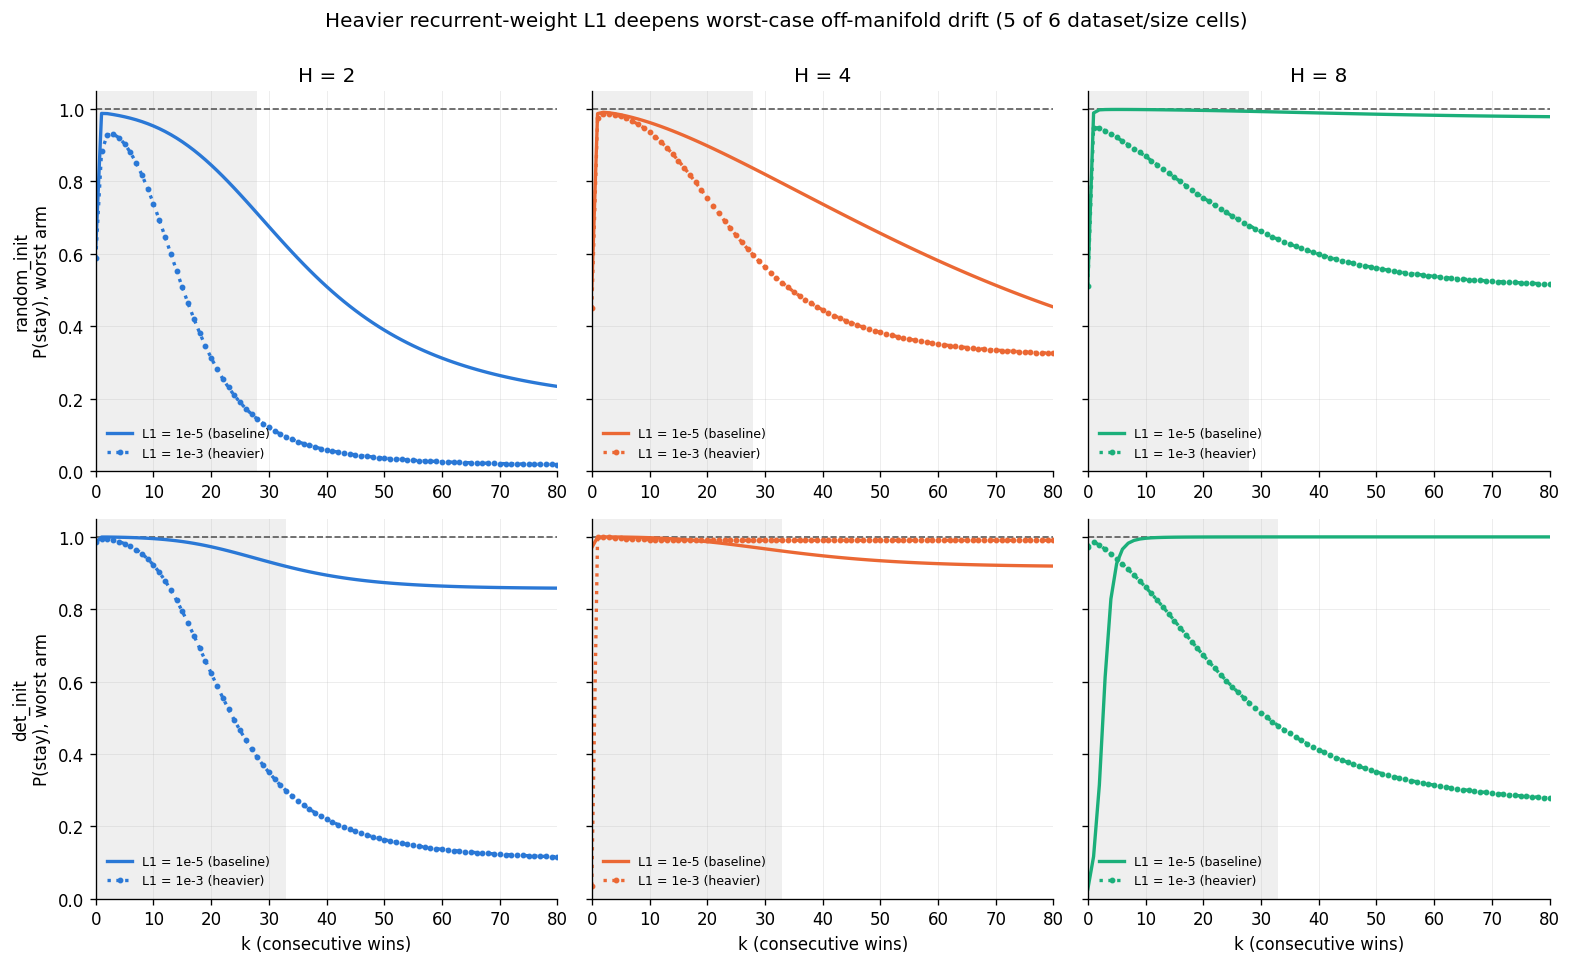

Worst-arm P(stay) at k=80  (lower = drifts further; * = heavier L1 drifts further):
  random_init
     H=2:  L1=1e-5 -> 0.234   L1=1e-3 -> 0.018   *
     H=4:  L1=1e-5 -> 0.453   L1=1e-3 -> 0.325   *
     H=8:  L1=1e-5 -> 0.979   L1=1e-3 -> 0.517   *
  det_init
     H=2:  L1=1e-5 -> 0.858   L1=1e-3 -> 0.116   *
     H=4:  L1=1e-5 -> 0.919   L1=1e-3 -> 0.990    
     H=8:  L1=1e-5 -> 1.000   L1=1e-3 -> 0.278   *


In [11]:
# --- 6b -- the same probe under a heavier L1 penalty, on every dataset that has an L1 sweep -
# Two datasets ship a committed L1=1e-3 sweep beside the 1e-5 baseline: random_init (this
# project) and det_init (added by the merged det-init branch). Each network breaks symmetry on
# its own arm (§5), so we compare each network's OWN worst arm: how far the more-drifting arm
# falls by k=KMAX. Rows are datasets, columns are hidden sizes.
L1_DATASETS = [name for name in ("random_init", "det_init")
               if load_rnn(name, DATA[name]["A"], DATA[name]["Y"], exp_suffix="_l1-0.001")]
_use_fsc_path()

def _worst_arm(probe_dict, H, A):        # lowest P(stay) at k=KMAX
    return min(range(A), key=lambda a: probe_dict[H][a]["pstay"][KMAX])

l1_probe = {}     # {dataset: {H: {arm: probe}}}
for name in L1_DATASETS:
    dd = DATA[name]
    rnn_l1 = load_rnn(name, dd["A"], dd["Y"], exp_suffix="_l1-0.001"); _use_fsc_path()
    l1_probe[name] = {H: {a0: rnn_probe(P, a0, dd["win_idx"], dd["A"], dd["Y"])
                          for a0 in range(dd["A"])} for H, P in rnn_l1.items()}

fig, axes = plt.subplots(len(L1_DATASETS), len(H_LIST),
                         figsize=(4.4 * len(H_LIST), 4.0 * len(L1_DATASETS)), sharey=True, squeeze=False)
worse = total = 0
for r, name in enumerate(L1_DATASETS):
    dd = DATA[name]; A = dd["A"]
    for c, H in enumerate(H_LIST):
        ax = axes[r, c]
        if H not in dd["probe"] or H not in l1_probe[name]:
            ax.set_visible(False); continue
        shade_indata(ax, dd["max_streak"], label=False)
        ax.axhline(1.0, color=C_RULE, ls="--", lw=1)
        ab = _worst_arm(dd["probe"], H, A)
        al = _worst_arm(l1_probe[name], H, A)
        base_end, l1_end = dd["probe"][H][ab]["pstay"][KMAX], l1_probe[name][H][al]["pstay"][KMAX]
        total += 1; worse += (l1_end < base_end)
        ax.plot(KGRID, dd["probe"][H][ab]["pstay"], color=C_H[H], lw=2.0, label="L1 = 1e-5 (baseline)")
        ax.plot(KGRID, l1_probe[name][H][al]["pstay"], color=C_H[H], lw=2.0, ls=":", marker="o",
                ms=2.5, label="L1 = 1e-3 (heavier)")
        ax.set_xlim(0, KMAX); ax.set_ylim(0, 1.05)
        if r == 0: ax.set_title(f"H = {H}")
        if r == len(L1_DATASETS) - 1: ax.set_xlabel("k (consecutive wins)")
        ax.legend(fontsize=7.5, loc="lower left")
    axes[r, 0].set_ylabel(f"{name}\nP(stay), worst arm")
fig.suptitle("Heavier recurrent-weight L1 deepens worst-case off-manifold drift "
             f"({worse} of {total} dataset/size cells)", y=1.0)
plt.tight_layout(); plt.show()

print(f"Worst-arm P(stay) at k={KMAX}  (lower = drifts further; * = heavier L1 drifts further):")
for name in L1_DATASETS:
    dd = DATA[name]; A = dd["A"]
    print(f"  {name}")
    for H in H_LIST:
        if H not in dd["probe"] or H not in l1_probe[name]:
            continue
        b = dd["probe"][H][_worst_arm(dd["probe"], H, A)]["pstay"][KMAX]
        l = l1_probe[name][H][_worst_arm(l1_probe[name], H, A)]["pstay"][KMAX]
        print(f"     H={H}:  L1=1e-5 -> {b:.3f}   L1=1e-3 -> {l:.3f}   {'*' if l < b else ' '}")

## 7. What this adds up to

1. **Matching behavior does not certify the policy.** On every dataset, across the trials that
occur, the FSC and the RNN land within about 0.002 of the real win-stay/lose-shift rates (§1). On
behavior alone they read as interchangeable, and that reading is wrong.

2. **The RNN never learned "always stay."** Fed a run of wins longer than the streaks in the data,
its confidence that it should stay falls (§2). The FSC answers 1.0 forever, because its transition
is a lookup on `(action, observation)` and has no off-manifold behavior to get wrong.

3. **It learned a slow transient toward the wrong fixed point.** On the failing arm the hidden state
keeps moving where a learned latch would have gone quiet (§3). Under unlimited winning evidence the
network converges stably, Jacobian spectral radius below 1, onto a fixed point whose readout is the
wrong certainty, often near-random or flipped (§4). The eigenvalues sit just under 1, so the
approach is slow enough to hide inside the streaks of at most 28 steps the data contains, which is
why training never penalized it.

4. **Capacity is not the limiter.** Every size reproduces WSLS in-band, and every size drifts one
arm out-of-band, a different arm each time depending on initialization (§5). Extra units relocate
the crack. Heavier L1 regularization deepens it (§6b).

5. **The one clean case is the one that needs no certainty.** On the stochastic `rwsls_det_init`,
the true rule is `P(stay|win)` near 0.67, and the RNN's fixed point lands there (§6). The failure is
specific: the network cannot hold an extreme 0 or 1 certainty off the data manifold, even for a
trivial rule seen across 1000 sessions.

**For the project.** A discrete controller and a small GRU can be behaviorally identical while
differing in kind. The FSC represents the rule; the RNN approximates it on the support of the data.
Any claim that "the RNN learned the strategy" has to be tested off the data manifold, since
on-distribution behavior cannot separate the two. This is the cleanest demonstration of that gap in
the pipeline, and the probe is the tool that makes it visible.

Scope: all five datasets are one-bit WSLS variants. That makes them the right setting to validate
the diagnostic, since we know the answer and the probe recovers it. It makes them the wrong setting
for claims about when RNN capacity pays off. The next test is a task with real multi-step memory.

## 8. Analytical GRU construction

The sections above study *trained* GRUs: fit by gradient descent, then probed off the data
manifold. This section builds a different kind of object -- a GRU whose weights are chosen by
hand to satisfy the WSLS update equations, not learned. The goal is not to find an optimum. It
is to exhibit one member of the (underdetermined) family of exact solutions, so it can serve as
a benchmark: if this analytically-constructed network holds up where the trained ones drift,
that is evidence the drift traces back to optimization, not to what a GRU can represent. §9
works out the math; §10 runs it through the same diagnostics already used above.

Implementation note on ordering: the steps below are grouped by dependency rather than strictly
by the order they were requested in -- the weight construction (8.2) has to exist before its
own fixed-point equation (8.3) or the trial timeline (8.4) can be evaluated against it. Nothing
is skipped; everything requested appears once, self-consistently.

In [12]:
# --- 8.1 -- verify assumptions before constructing anything --------------------------------
print("DATA['det_init']['win_idx']  =", DATA["det_init"]["win_idx"])
print("DATA['det_init']['lose_idx'] =", DATA["det_init"]["lose_idx"])
print("DATA['det_init']['ActSpace'] =", DATA["det_init"]["ActSpace"])
print("DATA['det_init']['ObsSpace'] =", DATA["det_init"]["ObsSpace"])

assert DATA["det_init"]["win_idx"] == 1, (
    "win_idx != 1: the weights below assume y1 = win (the second one-hot observation block, "
    "input columns [A+1]). If this fires, P_analytical_H1['W_ih']'s reset-gate row (row 0, "
    "columns A:A+Y) must have its two observation columns swapped before anything below is valid."
)
print("\nConfirmed: y1 = win for det_init. No reset-gate column swap needed.")

DATA['det_init']['win_idx']  = 1
DATA['det_init']['lose_idx'] = 0
DATA['det_init']['ActSpace'] = [-1  1]
DATA['det_init']['ObsSpace'] = [0 1]

Confirmed: y1 = win for det_init. No reset-gate column swap needed.


In [13]:
# --- 8.2 -- the analytical H=1 GRU: one sufficient-condition construction, not a fit --------
# Values given exactly, unmodified -- no tuning, no extra parameters, no readout bias. See §9 for
# what this construction does and does not claim.
H = 1
P_analytical_H1 = {
    "H": H,
    "W_ih": np.array([[0, 0, 8, -8], [0, 0, 0, 0], [4, -4, 0, 0]]),
    "b_ih": np.array([0, -10, 0]),
    "W_hh": np.array([[0], [0], [-10]]),
    "b_hh": np.array([0, 0, 0]),
    "lin_W": np.array([[10], [-10]]),
    "lin_b": np.array([0, 0]),
}
print("P_analytical_H1 =")
for k, v in P_analytical_H1.items():
    print(f"   {k:>6s} = {v.tolist() if hasattr(v, 'tolist') else v}")

P_analytical_H1 =
        H = 1
     W_ih = [[0, 0, 8, -8], [0, 0, 0, 0], [4, -4, 0, 0]]
     b_ih = [0, -10, 0]
     W_hh = [[0], [0], [-10]]
     b_hh = [0, 0, 0]
    lin_W = [[10], [-10]]
    lin_b = [0, 0]


In [14]:
# --- 8.3 -- h_min_full: numerical root of the exact fixed-point equation for the "repeatedly
# choose arm 0, repeatedly lose" branch, via scipy.optimize.brentq. Nothing here is hardcoded --
# every constant (z, r, the candidate's input drive, the recurrent coupling) is read out of
# P_analytical_H1 itself, using gru_step's own equations (§0.1), then handed to brentq.
from scipy.optimize import brentq

P = P_analytical_H1
wi_det, li_det = DATA["det_init"]["win_idx"], DATA["det_init"]["lose_idx"]

x_lose_a0 = encode_input(0, li_det, 2, 2)                # (action=0, observation=lose)
gi = P["W_ih"] @ x_lose_a0 + P["b_ih"]                     # input-driven pre-activations
z_const = _sigmoid(gi[1])            # update gate: W_hh row 1 is all zero -> input-only
r_const = _sigmoid(gi[0])            # reset gate:  W_hh row 0 is all zero -> input-only
gi2     = gi[2]                      # candidate's input drive on this branch
w_hh2   = P["W_hh"][2, 0]            # candidate's recurrent coupling

print(f"branch: action=0, observation=lose (x = {x_lose_a0})")
print(f"z (update gate) = sigmoid({gi[1]:.4f}) = {z_const:.8e}")
print(f"r (reset gate)  = sigmoid({gi[0]:.4f}) = {r_const:.8f}")
print(f"candidate input drive gi[2] = {gi2:.4f}")
print(f"recurrent coupling W_hh[2,0] = {w_hh2:.4f}")

def h_min_residual(h):
    n = np.tanh(gi2 + r_const * w_hh2 * h)
    h_next = (1 - z_const) * n + z_const * h
    return h_next - h

h_min_full = brentq(h_min_residual, -1.0, 1.0, xtol=1e-14)
print(f"\nh_min_full = {h_min_full!r}")
print("(numerical root of the exact equation "
      f"(1-z)*tanh({gi2:.0f} - {-w_hh2:.0f}*sigmoid({gi[0]:.0f})*h) + z*h = h, via brentq)")

branch: action=0, observation=lose (x = [1. 0. 1. 0.])
z (update gate) = sigmoid(-10.0000) = 4.53978687e-05
r (reset gate)  = sigmoid(8.0000) = 0.99966465
candidate input drive gi[2] = 4.0000
recurrent coupling W_hh[2,0] = -10.0000

h_min_full = 0.3621819563588162
(numerical root of the exact equation (1-z)*tanh(4 - 10*sigmoid(8)*h) + z*h = h, via brentq)


In [15]:
# --- 8.4 -- trial timeline: verify the temporal indexing before defining any evaluation
# metrics. H_t is the state going INTO trial t (used to predict the action AT t); the real
# (a_t, o_t) then produces H_{t+1}. This is the same convention §0.2's model_rates already uses
# (rnn_step there: p = rnn_action_probs(h, P) BEFORE consuming (a[t], o[t])) -- confirmed here by
# direct inspection, not assumed.
sess = DATA["det_init"]["sessions"][0]
A_det, Y_det = DATA["det_init"]["A"], DATA["det_init"]["Y"]
h = np.zeros(1)
print(f"{'t':>3} {'H_t':>10} {'pred action_t':>15} {'actual (a_t,o_t)':>18} {'H_t+1':>10}")
for t in range(8):
    probs = rnn_action_probs(h, P_analytical_H1)
    pred = int(np.argmax(probs))
    a_t, o_t = int(sess["actions"][t]), int(sess["observations"][t])
    h_next, _ = gru_step(h, encode_input(a_t, o_t, A_det, Y_det), P_analytical_H1)
    print(f"{t:>3} {h[0]:>10.4f} {pred:>15d} {'(' + str(a_t) + ',' + str(o_t) + ')':>18} {h_next[0]:>10.4f}")
    h = h_next

  t        H_t   pred action_t   actual (a_t,o_t)      H_t+1
  0     0.0000               0              (0,0)     0.9993
  1     0.9993               0              (1,0)    -0.9999
  2    -0.9999               1              (0,0)     0.9999
  3     0.9999               0              (1,0)    -0.9999
  4    -0.9999               1              (0,1)     0.9992
  5     0.9992               0              (0,1)     0.9993
  6     0.9993               0              (0,1)     0.9993
  7     0.9993               0              (0,1)     0.9993


In [16]:
# --- 8.5 -- free-running evaluation: checked whether it's possible, and it isn't -----------
# Searched FSC-inference-MAPSO/src/environments/ (SymmetricTwoArmsBernoulliBandits,
# base_environment_model.py) and tinyRNN/simulating_experiments/simulate_experiment.py: neither
# implements THIS dataset's generative rule (whatever produced wsls_actions_observations_det_
# init.npz) as a function of an arbitrary action sequence -- only generic bandit environments and
# cognitive-model simulators exist.
#
# Consequence: no model here can be free-run (fed its own chosen actions and receive consistent
# outcomes back). The moment a model's action diverges from the recorded one, the next recorded
# outcome was generated in response to a DIFFERENT action -- reusing it would pass off off-policy
# data as on-policy. So every comparison in §8 and §10 stays teacher-forced: real recorded
# (action, outcome) pairs replayed through each model, exactly as §0.2's model_rates already
# does. No free-running comparison is attempted anywhere in this notebook.
print("No outcome-generating environment for this dataset found in the repo -- "
      "free-running evaluation omitted; every comparison below is teacher-forced.")

No outcome-generating environment for this dataset found in the repo -- free-running evaluation omitted; every comparison below is teacher-forced.


In [17]:
# --- 8.6 -- four-case steady-state verification, using gru_step directly (§0.1, unmodified) --
def _report_step(label, h_in, a, y):
    x = encode_input(a, y, 2, 2)
    h_out, gates = gru_step(np.array([h_in]), x, P_analytical_H1)
    probs = rnn_action_probs(h_out, P_analytical_H1)
    pred = int(np.argmax(probs))
    print(f"{label:<22} h_in={h_in:+.4f}  x={x}  "
          f"r={gates['reset'][0]:.5f} z={gates['update'][0]:.5f} n={gates['new'][0]:+.5f}  "
          f"h_out={h_out[0]:+.5f}  P(a)={np.round(probs, 4)}  predicted next action={pred}")
    return h_out[0], pred

# steady "currently committed to arm X" incoming states, derived from the model's own win-branch
# candidate drive (gi[2] = +-4), not a second independent magic number
h_committed_a0 = float(np.tanh(P_analytical_H1["W_ih"][2, 0]))   # ~ +0.9993
h_committed_a1 = -h_committed_a0                                  # ~ -0.9993
print(f"Steady incoming states used below: h(committed to arm0)={h_committed_a0:+.5f}  "
      f"h(committed to arm1)={h_committed_a1:+.5f}\n")

cases = [
    ("arm0 + win",  h_committed_a0, 0, wi_det, 0),   # expect: stay on arm 0
    ("arm0 + loss", h_committed_a0, 0, li_det, 1),   # expect: shift to arm 1
    ("arm1 + win",  h_committed_a1, 1, wi_det, 1),   # expect: stay on arm 1
    ("arm1 + loss", h_committed_a1, 1, li_det, 0),   # expect: shift to arm 0
]
all_ok = True
for label, h_in, a, y, expected_next_action in cases:
    _, pred = _report_step(label, h_in, a, y)
    ok = (pred == expected_next_action)
    all_ok &= ok
    print(f"   -> WSLS-consistent: {ok}\n")
print("All four steady-state cases WSLS-consistent:", all_ok)

print("\n--- h0 = 0, tested separately (the known initialization limitation) ---")
print("(P(a0)=[0.5,0.5] at h0 regardless of what comes next -- readout of an all-zero state is "
      "symmetric. What matters here is what h0 -> h1 does, and whether it depends on the outcome.)")
for a in (0, 1):
    for y_label, y in [("win", wi_det), ("loss", li_det)]:
        _report_step(f"h0=0, a={a}, {y_label}", 0.0, a, y)

Steady incoming states used below: h(committed to arm0)=+0.99933  h(committed to arm1)=-0.99933

arm0 + win             h_in=+0.9993  x=[1. 0. 0. 1.]  r=0.00034 z=0.00005 n=+0.99932  h_out=+0.99932  P(a)=[1. 0.]  predicted next action=0
   -> WSLS-consistent: True

arm0 + loss            h_in=+0.9993  x=[1. 0. 1. 0.]  r=0.99966 z=0.00005 n=-0.99999  h_out=-0.99990  P(a)=[0. 1.]  predicted next action=1
   -> WSLS-consistent: True

arm1 + win             h_in=-0.9993  x=[0. 1. 0. 1.]  r=0.00034 z=0.00005 n=-0.99932  h_out=-0.99932  P(a)=[0. 1.]  predicted next action=1
   -> WSLS-consistent: True

arm1 + loss            h_in=-0.9993  x=[0. 1. 1. 0.]  r=0.99966 z=0.00005 n=+0.99999  h_out=+0.99990  P(a)=[1. 0.]  predicted next action=0
   -> WSLS-consistent: True

All four steady-state cases WSLS-consistent: True

--- h0 = 0, tested separately (the known initialization limitation) ---
(P(a0)=[0.5,0.5] at h0 regardless of what comes next -- readout of an all-zero state is symmetric. What 

## 9. Mathematical explanation

**Scope.** This is one sufficient-condition construction (*exact derivation*: the four-case
check in §8.6 verifies it satisfies WSLS at the steady states by direct computation). Nothing
here was minimized or fit; no claim is made that it is optimal, or that it is the unique H=1
solution -- other sign/scale choices, or entirely different weight assignments, could satisfy
the same four steady-state conditions.

**Why an input-only affine map can\'t do this (exact derivation, limited to this encoding).**
Could a stateless, purely affine readout of the one-hot input `x = (a_t, y_t)` -- no recurrence,
no hidden state at all -- implement the WSLS rule directly? Write the logit difference (action-0
logit minus action-1 logit) as an affine function of `x`. Because `x` is a one-hot pair, exactly
one action-bit and one observation-bit are active, so the logit difference decomposes as
`d(a, y) = c_a + c_y + d0` for constants indexed by which bit is on. WSLS requires:

- `d(a=0, win)  > 0`  (stay on 0)
- `d(a=0, lose) < 0`  (shift to 1)
- `d(a=1, win)  < 0`  (stay on 1)
- `d(a=1, lose) > 0`  (shift to 0)

Subtracting the first pair: `d(a=0,win) - d(a=0,lose) = c_win - c_lose > 0` (positive minus
negative). Subtracting the second pair: `d(a=1,win) - d(a=1,lose) = c_win - c_lose < 0` (negative
minus positive). Both can\'t hold -- `c_win - c_lose` cannot be simultaneously positive and
negative. **Contradiction.** No affine map of this one-hot `(a_t, y_t)` encoding, with any
weights, can produce the WSLS decision. The reason is structural: "stay" requires *action* and
*outcome* to interact (stay iff action and win agree in a specific way), and a sum of two
independent one-hot blocks cannot express that interaction -- this is the same obstruction as
XOR not being linearly separable. This conclusion is specific to *this* input encoding and *this*
architecture (a single-layer affine map of one-hot blocks); a different feature encoding (e.g. an
explicit product feature) could resolve it without recurrence.

**Why the recurrent pathway is what fixes it (exact derivation).** `P_analytical_H1`\'s reset
gate `r` is a function of the observation alone (`W_hh` row 0 is zero), and the candidate\'s
recurrent term is `r * W_hh[2,0] * h`. Since `h` itself encodes *which action was last
committed to* (its sign, via the `+-4` candidate drive), the product `r(y) * h(a_prev)` is
exactly the action-outcome interaction term the affine argument above showed is unreachable
without one. The recurrence isn\'t incidental here -- it\'s the multiplicative term that makes
the construction possible at all.

**Claim A vs. Claim B.** Two different statements are easy to conflate:
- **Claim A** (tautological): the hidden state determines the model\'s own action, via the
  readout. True by construction of any GRU + softmax readout; says nothing about correctness.
- **Claim B**: whether the actions this construction picks match the *real* WSLS policy.

**Where Claim B\'s induction breaks (exact derivation, specific to this construction).** An
inductive argument for Claim B works fine once the state is "committed" (§8.6\'s four steady
cases all check out). It fails at the very first transition, and specifically when the first
observed outcome is a **loss**. At `h0 = 0`, the recurrent term `r * W_hh[2,0] * h0` is exactly
zero regardless of `r` -- so `h1 = tanh(gi2)`, driven *only* by which action was taken at `t=0`,
not by whether it won or lost (verified directly in §8.6\'s `h0=0` block: `h_out` has the same
sign for both `win` and `loss` given the same action). If that first trial was a loss, WSLS says
"shift" -- but `h1` still points toward the action just taken, so the readout says "stay." This
is a limitation **of this particular H=1 construction's handling of the very first trial**, not
a claim about all possible H=1 GRUs (a construction with a nonzero `h0`, or a different
`W_hh`/`b_ih` design, could avoid it).

A direct consequence: `P(a_0) = [0.5, 0.5]` always under this construction (softmax of `lin_W @
h0 = lin_W @ 0 = [0,0]`, exactly, every session, regardless of what happens after). This
construction models the **steady-state WSLS transition rule**, not episode initialization -- and
makes no claim to.

**h_min_full and the reachable region.** `h_min_full` (§8.3, a *numerical* root of an *exact*
closed-form equation) is where the hidden state would settle under a hypothetical repeated
"choose arm 0, keep losing" branch -- i.e. the pull the recurrent term exerts against the
`+4` candidate drive when `r` is fully open (`r = sigmoid(8) \approx 0.9997` on the loss branch).
The reachable invariant region of `h` under the full update (§10\'s `rnn_fixed_point`, an
*empirical/numerical* fixed-point iteration of the actual `gru_step`, not the candidate
activation alone) sits between roughly this value and the symmetric win-branch fixed point near
`tanh(4) \approx 0.9993` (the win branch has `r = sigmoid(-8) \approx 4.5\times10^{-5}`, so the
recurrent pull there is nearly negligible but not exactly zero, unlike the idealized `r=0`
limit).

**The regularization hypothesis, stated carefully.** Reducing weight magnitude (heavier L1, as
in §6b) can change the confidence margin (`+-4`, `+-8`, `+-10` here) and shift where the
resulting fixed point sits -- that much follows from the equations above. Whether it also changes
the *spectral radius* or convergence *speed* toward a fixed point is **not** implied by this
construction\'s algebra; §6b measured a correlation (heavier L1 -> deeper worst-case drift) but
that is an *empirical observation* about trained networks, not a mathematical consequence proven
here. Treat it as an open question, not a conclusion.

## 10. Analytical versus trained comparison

Everything below reuses diagnostics already defined in §0 (`rnn_probe`, `rnn_fixed_point`,
`gru_step`, `encode_input`) and the plotting style from §0.3 (`shade_indata`, `C_RULE`, `C_H`,
`KGRID`, `KMAX`). No training is rerun and no existing cell or plot above this point is touched.

Three models are compared, all evaluated by teacher-forced replay against `det_init`'s real
sessions (§8.5 explains why nothing is free-run): the trained deterministic-task H=1 GRU, the
trained random-task H=1 GRU (evaluated out-of-distribution, on `det_init`'s sessions), and the
analytical H=1 GRU from §8.

In [18]:
# --- 10.1 -- load the trained H=1 GRUs. Not already in DATA: §0.1's load_rnn only extracts
# H in H_LIST = [2, 4, 8] (a hardcoded loop, inside the frozen §0). Trained H=1 fits exist on
# disk for both datasets (fitted_models/{name}/rnn/exp_{name}/...hidden_dim-1...); this reuses
# exactly the same building blocks §0.1 already defines (_use_tinyrnn_path, Agent,
# select_final_rnn_perf, extract_gru_params) called directly for H=1, instead of touching
# load_rnn or H_LIST.
def load_trained_H1(name, A, Y):
    _use_tinyrnn_path()
    exp = EXP_OVERRIDE.get(name, f"exp_{name}")
    live = f"files/saved_model/{exp}"
    arch = os.path.join(REPO, "fitted_models", name, "rnn", exp)
    cwd = os.getcwd(); os.chdir("tinyRNN")
    try:
        if os.path.isdir(arch) and not os.path.isdir(live):
            shutil.copytree(arch, live)
        from agents import Agent
        from analyzing_experiments.analyzing_perf import select_final_rnn_perf
        _, summary, _ = select_final_rnn_perf(exp, return_dim_est=True, verbose=False)
        rows = summary[summary["hidden_dim"] == 1].sort_values("trainval_loss")
        assert len(rows) > 0, f"no trained H=1 model found for {name!r}"
        cfg = {"agent_type": "RNN", "rnn_type": "GRU", "input_dim": A + Y, "hidden_dim": 1,
               "output_dim": A, "device": "cpu", "output_h0": True, "trainable_h0": False,
               "readout_FC": True, "one_hot": False, "seed": 0}
        ag = Agent("RNN", config=cfg); ag.load(str(rows.iloc[0]["model_path"]))
        return extract_gru_params(ag)
    finally:
        os.chdir(cwd)

d_det, d_rand = DATA["det_init"], DATA["random_init"]
P_trained_det1  = load_trained_H1("det_init",    d_det["A"],  d_det["Y"])
P_trained_rand1 = load_trained_H1("random_init", d_rand["A"], d_rand["Y"])
_use_fsc_path()

MODELS_10 = {
    "trained det_init H=1":    P_trained_det1,
    "trained random_init H=1": P_trained_rand1,
    "analytical H=1":          P_analytical_H1,
}
C_MODEL  = {"trained det_init H=1": C_H[2], "trained random_init H=1": C_H[4],
            "analytical H=1": "#111111"}
LS_MODEL = {"trained det_init H=1": "-",    "trained random_init H=1": "-",
            "analytical H=1": "--"}
print("Loaded H=1 models:", {k: v["H"] for k, v in MODELS_10.items()})

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}



  0%|          | 0/8 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 2386.52it/s]

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}



  0%|          | 0/8 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 2399.66it/s]

Loaded H=1 models: {'trained det_init H=1': 1, 'trained random_init H=1': 1, 'analytical H=1': 1}


In [19]:
# --- 10.2 -- teacher-forced cross-entropy: full-session, excluding init, init-only ----------
# Mirrors model_rates's (§0.2) replay structure and t-indexing (verified live in §8.4): the
# probability printed at step t is P(action_t | H_t), i.e. computed BEFORE consuming (a_t, o_t).
# Simplified to RNN-only (no FSC/step_probs abstraction, since every model here is a GRU) but the
# loop shape -- read out, then update state with the real trial -- is the same protocol, not a
# new one.
def teacher_forced_ce(P, sessions, A, Y):
    non_init, init_only = [], []
    for s in sessions:
        a, o = s["actions"], s["observations"]
        h = np.zeros(P["H"])
        for t in range(len(a)):
            p = rnn_action_probs(h, P)
            nll = -np.log(max(p[a[t]], 1e-300))
            (init_only if t == 0 else non_init).append(nll)
            h, _ = gru_step(h, encode_input(a[t], o[t], A, Y), P)
    full_ce      = float(np.mean(init_only + non_init))
    ce_excl_init = float(np.mean(non_init))
    init_only_ce = float(np.mean(init_only))
    return full_ce, ce_excl_init, init_only_ce

print(f"{'model':<28} {'full CE':>10} {'CE excl. init':>15} {'init-only CE':>14}")
ce_results = {}
for label, P in MODELS_10.items():
    res = teacher_forced_ce(P, d_det["sessions"], d_det["A"], d_det["Y"])
    ce_results[label] = res
    print(f"{label:<28} {res[0]:>10.4f} {res[1]:>15.4f} {res[2]:>14.4f}")

analytical_init_ce = ce_results["analytical H=1"][2]
print(f"\nAnalytical model's init-only CE = {analytical_init_ce:.6f}   "
      f"(-log(0.5) = {-np.log(0.5):.6f})   match = {np.isclose(analytical_init_ce, -np.log(0.5))}")

model                           full CE   CE excl. init   init-only CE


trained det_init H=1             0.0034          0.0020         0.2814


trained random_init H=1          0.0067          0.0020         0.9368


analytical H=1                   0.0855          0.0825         0.6931

Analytical model's init-only CE = 0.693147   (-log(0.5) = 0.693147)   match = True


In [20]:
# --- 10.2b -- CE breakdown: by previous outcome, and by first-post-init vs. later transition -
# Diagnoses where §10.2's elevated "CE excl. init" for the analytical model (0.0825, vs ~0.002
# for the trained models) actually comes from: the h0=0 first-loss failure §9 derives (which
# would concentrate excess CE at t==1, the first post-init transition), or something spread more
# evenly across later, steady-state trials (t>=2) instead -- e.g. paying a large penalty on the
# real data's rare WSLS-violating "lapse" trials, which can occur at any t.
wi_bd, li_bd = d_det["win_idx"], d_det["lose_idx"]

def teacher_forced_ce_breakdown(P, sessions, A, Y, wi, li):
    """Per-trial -log p(a_t | H_t) for t>=1 (post-init), tagged by (previous outcome, whether
    this is the first post-init transition t==1 or a later one t>=2). Same replay protocol and
    t-indexing as teacher_forced_ce (§10.2) -- this just keeps the per-trial tags instead of
    collapsing straight to a mean."""
    rows = []
    for s in sessions:
        a, o = s["actions"], s["observations"]
        h = np.zeros(P["H"])
        for t in range(len(a)):
            p = rnn_action_probs(h, P)
            if t >= 1:
                nll = -np.log(max(p[a[t]], 1e-300))
                prev = "win" if o[t - 1] == wi else "lose"
                rows.append((prev, "t=1 (first)" if t == 1 else "t>=2 (later)", nll))
            h, _ = gru_step(h, encode_input(a[t], o[t], A, Y), P)
    return pd.DataFrame(rows, columns=["prev_outcome", "transition", "nll"])

print(f"{'model':<28} {'prev outcome':>13} {'transition':>13} {'n':>8} {'mean CE':>9}")
for label, P in MODELS_10.items():
    df = teacher_forced_ce_breakdown(P, d_det["sessions"], d_det["A"], d_det["Y"], wi_bd, li_bd)
    g = df.groupby(["prev_outcome", "transition"])["nll"].agg(["count", "mean"]).reset_index()
    g = g.sort_values(["transition", "prev_outcome"])
    for _, row in g.iterrows():
        print(f"{label:<28} {row['prev_outcome']:>13} {row['transition']:>13} "
              f"{int(row['count']):>8} {row['mean']:>9.4f}")
    total_n = g["count"].sum()
    weighted = float((g["count"] * g["mean"]).sum() / total_n)
    print(f"{'':<28} {'[check] weighted mean over breakdown':>27} = {weighted:.4f}  "
          f"(should match §10.2's CE excl. init for this model)\n")

model                         prev outcome    transition        n   mean CE


trained det_init H=1                  lose   t=1 (first)      496    0.0027
trained det_init H=1                   win   t=1 (first)      504    0.0042
trained det_init H=1                  lose  t>=2 (later)    82816    0.0020
trained det_init H=1                   win  t>=2 (later)   115184    0.0021
                             [check] weighted mean over breakdown = 0.0020  (should match §10.2's CE excl. init for this model)



trained random_init H=1               lose   t=1 (first)      496    0.0011
trained random_init H=1                win   t=1 (first)      504    0.0170
trained random_init H=1               lose  t>=2 (later)    82816    0.0020
trained random_init H=1                win  t>=2 (later)   115184    0.0020
                             [check] weighted mean over breakdown = 0.0020  (should match §10.2's CE excl. init for this model)



analytical H=1                        lose   t=1 (first)      496   19.9857
analytical H=1                         win   t=1 (first)      504    0.0000
analytical H=1                        lose  t>=2 (later)    82816    0.0785
analytical H=1                         win  t>=2 (later)   115184    0.0000
                             [check] weighted mean over breakdown = 0.0825  (should match §10.2's CE excl. init for this model)



In [21]:
# --- 10.3 -- parameter norms ------------------------------------------------------------------
def penalized_l1_norm(P):
    """sum|W_ih| + sum|W_hh| -- exactly what tinyRNN's L1 penalizes when penalized_weight='rec'.
    Verified against tinyRNN/agents/RNNAgentTrainer.py (not assumed): it penalizes every named
    parameter containing BOTH 'weight' and 'rnn' in its name, which is W_ih and W_hh (both
    live under the model's 'rnn.' submodule) -- biases and the lin (readout) weight/bias are
    excluded. The pipeline's base_config sets penalized_weight='rec' for every dataset trained
    here, so this is the literal quantity l1_weight scales, not just a proxy for it."""
    return float(np.abs(P["W_ih"]).sum() + np.abs(P["W_hh"]).sum())

print(f"{'model':<28} {'sum|W_ih|+|W_hh|':>18}")
for label, P in MODELS_10.items():
    print(f"{label:<28} {penalized_l1_norm(P):>18.3f}")

model                          sum|W_ih|+|W_hh|
trained det_init H=1                     26.350
trained random_init H=1                  26.819
analytical H=1                           34.000


In [22]:
# --- 10.4 -- fixed-point analysis, via rnn_fixed_point() (§0.2, unmodified) -----------------
# Same usage pattern as §4: feed each arm the SAME (arm, win) input repeatedly and see where the
# full GRU update (not just the candidate) settles. spec_radius is read directly from the
# function's own Jacobian eigenvalues, not inferred from a plot.
wi = d_det["win_idx"]
print(f"{'model':<28} {'arm':>4} {'fp P(stay)':>11} {'spectral radius':>16}")
for label, P in MODELS_10.items():
    for a0 in (0, 1):
        fp = rnn_fixed_point(P, a0, wi, 2, 2)
        print(f"{label:<28} {a0:>4} {fp['pstay']:>11.4f} {fp['spec_radius']:>16.4f}")

model                         arm  fp P(stay)  spectral radius
trained det_init H=1            0      0.9996           0.1669
trained det_init H=1            1      0.0002           0.9665
trained random_init H=1         0      0.9983           0.4924
trained random_init H=1         1      0.0016           0.9950
analytical H=1                  0      1.0000           0.0000
analytical H=1                  1      1.0000           0.0000


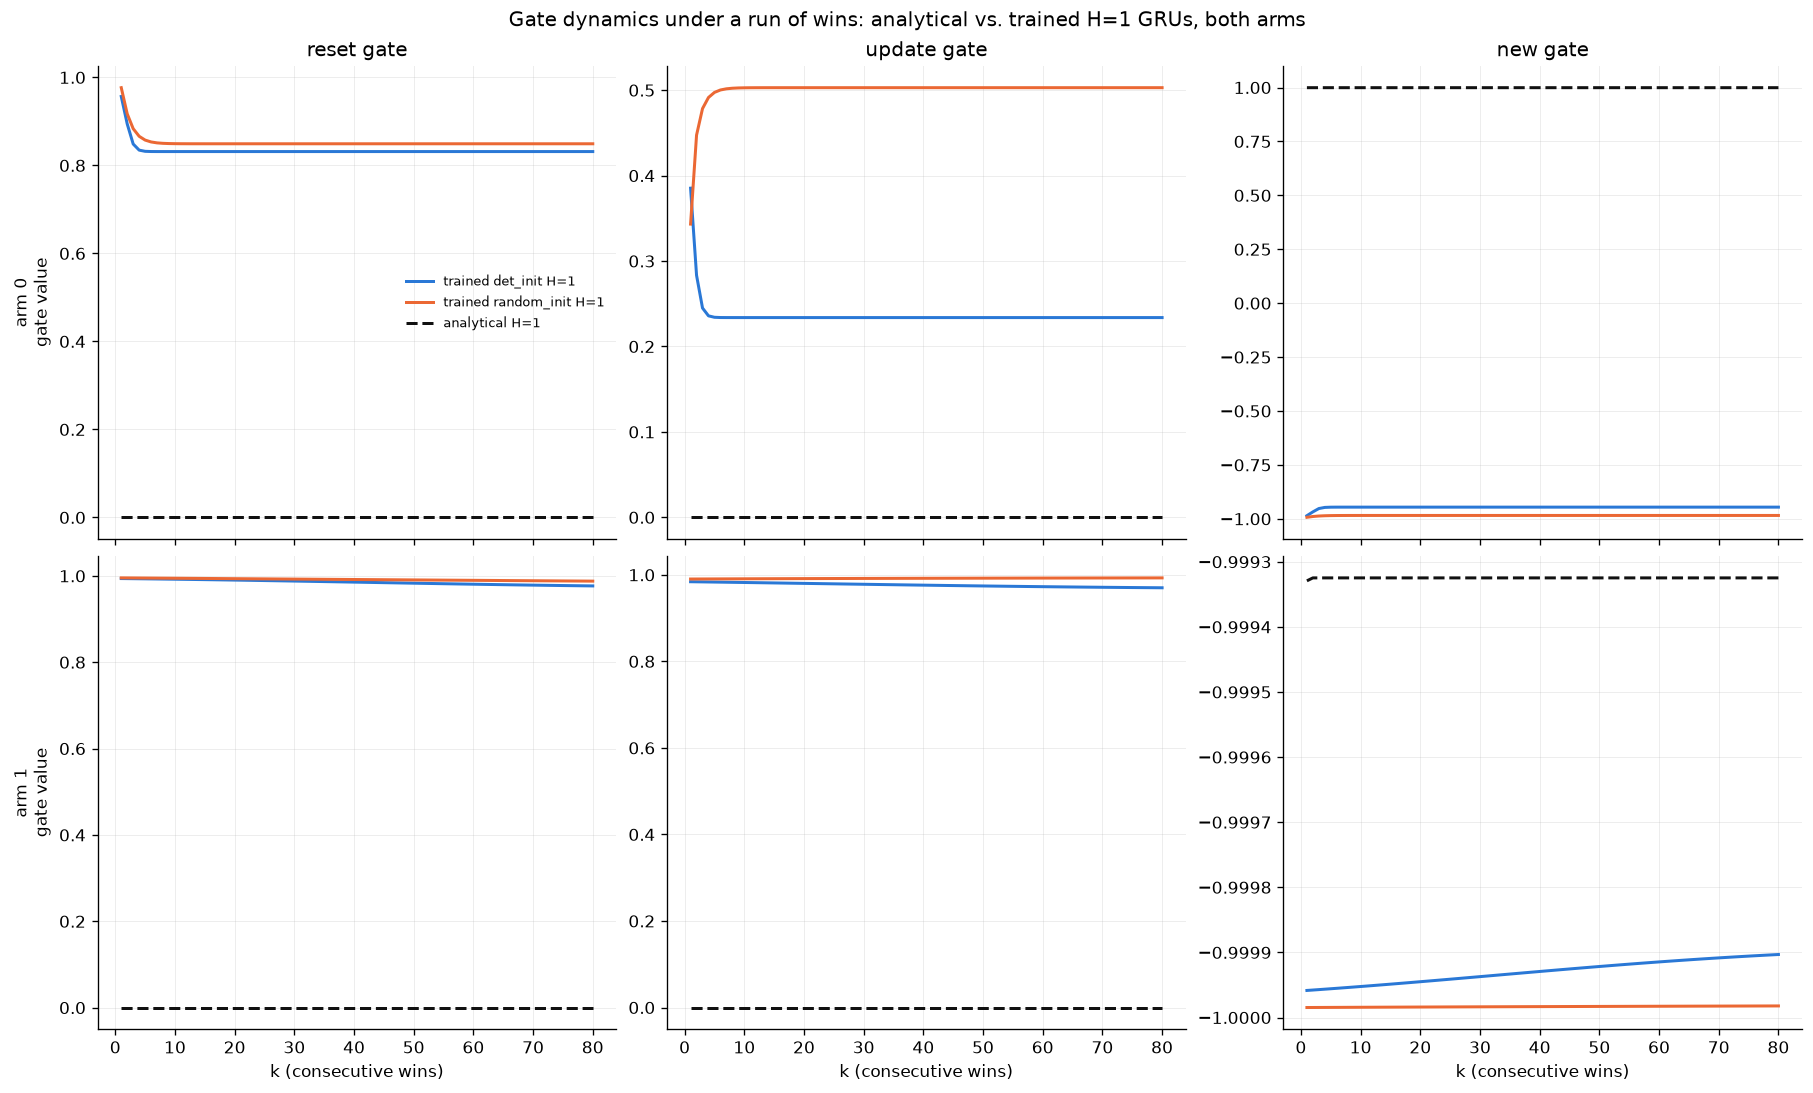

In [23]:
# --- 10.5 -- gate dynamics, via rnn_probe() (§0.2, unmodified), same style as §3/§5 -----------
# Both arms shown: the §10.4 fixed-point table shows arm 1 is where both trained H=1 models
# actually fail (P(stay) fixed point 0.0002 / 0.0016), while arm 0 is where both happen to hold
# -- a single-arm plot would only ever show the arm that succeeds, silently hiding the failure
# this section exists to compare against. constrained_layout (not tight_layout) reserves space
# for the suptitle on its own, so the top row's titles don't crowd it.
fig, axes = plt.subplots(2, 3, figsize=(15, 9.0), sharex=True, constrained_layout=True)
for row, a0 in enumerate((0, 1)):
    for col, gname in enumerate(("reset", "update", "new")):
        ax = axes[row, col]
        for label, P in MODELS_10.items():
            probe = rnn_probe(P, a0, wi, 2, 2, kmax=KMAX)   # arm a0, fed a run of wins
            vals = [g[gname][0] for g in probe["gates"]]
            ax.plot(KGRID[1:], vals, color=C_MODEL[label], ls=LS_MODEL[label], lw=1.8, label=label)
        if row == 0:
            ax.set_title(f"{gname} gate")
        if row == 1:
            ax.set_xlabel("k (consecutive wins)")
    axes[row, 0].set_ylabel(f"arm {row}\ngate value")
axes[0, 0].legend(fontsize=8, loc="center right")
fig.suptitle("Gate dynamics under a run of wins: analytical vs. trained H=1 GRUs, both arms")
plt.show()

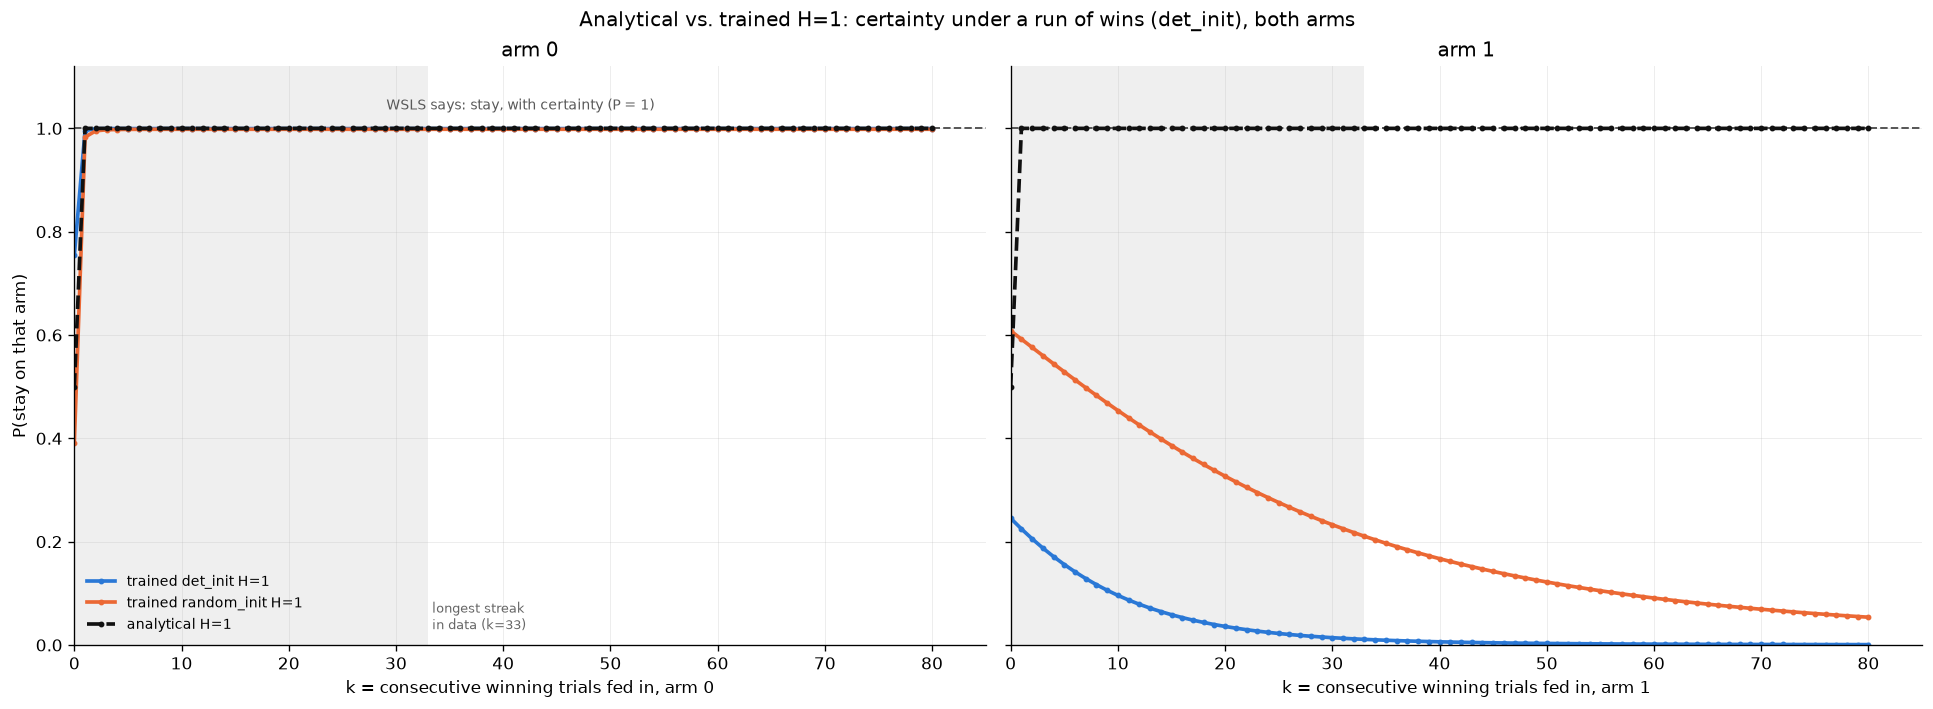

In [24]:
# --- 10.6 -- long-streak overlay, same plotting style as §2's hero decay curve (that cell is
# not modified -- this is a standalone figure). Both arms shown, side by side, for the same
# reason as §10.5: arm 1 is where the trained H=1 models actually drift (§10.4); a single-arm
# plot picked arm 0 the first time around and happened to hide that entirely.
# constrained_layout (not tight_layout) reserves space for the suptitle on its own.
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), sharey=True, constrained_layout=True)
for ax, a0 in zip(axes, (0, 1)):
    shade_indata(ax, d_det["max_streak"], label=(a0 == 0))
    ax.axhline(1.0, color=C_RULE, ls="--", lw=1.2)
    for label, P in MODELS_10.items():
        probe = rnn_probe(P, a0, wi, 2, 2, kmax=KMAX)
        ax.plot(KGRID, probe["pstay"], color=C_MODEL[label], ls=LS_MODEL[label], lw=2.2,
                marker="o", ms=2.5, label=label)
    ax.set_xlim(0, KMAX + 5); ax.set_ylim(0, 1.12)
    ax.set_xlabel(f"k = consecutive winning trials fed in, arm {a0}")
    ax.set_title(f"arm {a0}")
axes[0].set_ylabel("P(stay on that arm)")
axes[0].text(KMAX * 0.52, 1.03, "WSLS says: stay, with certainty (P = 1)", fontsize=8.5,
             color=C_RULE, ha="center", va="bottom")
axes[0].legend(loc="lower left", fontsize=8.5)
fig.suptitle("Analytical vs. trained H=1: certainty under a run of wins (det_init), both arms")
plt.show()

## 11. Discussion

**Two different scientific questions.** "The architecture can represent this behavior" and
"gradient descent reliably discovers that representation" are not the same claim. §8-9 answer
the first: an H=1 GRU *can* exactly satisfy WSLS's steady-state transitions (four-case check,
§8.6) via a specific, hand-built set of weights, and §9 shows why the recurrent pathway is what
makes that possible for this encoding. That says nothing on its own about what gradient descent,
starting from a generic initialization and optimizing a behavioral loss plus L1, will find.

**If the analytical model holds up where trained ones drift.** Should §10's results show the
analytical H=1 network's fixed points and long-streak behavior staying near the correct WSLS
certainty while the trained det_init H=1 network drifts (the failure mode §1-§6 document at
larger H), that is consistent with the earlier hypothesis that the gap traces to optimization
rather than to GRU capacity -- since a solution both networks are capable of representing was
harder for one of them to find under gradient descent. It does not, on its own, prove
optimization is *the* cause: the trained network differs from the analytical one in several
ways at once (initialization, the L1 penalty actually applied during training, the finite
26-session training signal, the particular local optimum reached), and §10's measurements
(parameter norms, spectral radii, gate dynamics) are what let each of those be examined
individually rather than left bundled into one claim. If, for instance, the trained model's
fixed point sits closer to correct than its parameter norm alone would suggest, that argues
against regularization strength being the dominant factor here; if the two diverge sharply in
spectral radius despite similar norms, that points toward optimization dynamics rather than the
penalty's magnitude.

**If the analytical model fails under the tested conditions instead.** That would point at a
problem with this *particular* construction (the four-case check in §8.6 already flags the known
first-loss failure at `h0=0` as one such limitation) or possibly at a genuine limit of what H=1
can represent for this task -- not at gradient descent, and not at H=1 GRUs in general beyond
what was actually tested here (one dataset, one construction, one set of diagnostics).

**The initialization limitation, restated.** §9 derived, and §8.6 verified directly, that this
construction has no mechanism for handling the very first trial of a session: `h0 = 0` erases
the recurrent term entirely, so the first transition depends only on which action was taken, not
on whether it won or lost. `P(a_0) = [0.5, 0.5]` always, by construction. This is a known,
explicit property of the *steady-state* benchmark built here, not an oversight -- the
construction is offered as a benchmark for how a GRU behaves once evidence has accumulated, the
same off-manifold regime §1-§6 probe, not as a full model of a WSLS episode from its first
trial.

## 12. Analytical GRU construction: H=2 and H=4

Extends the H=1 benchmark (§8-11) with three more analytically-constructed GRUs, to answer a
narrower version of the same question: does H=1's known startup limitation (§9: no mechanism
for "first outcome is a loss") require *more capacity*, or just a *different, still hand-built*
mechanism? Four analytical dictionaries in total, not five:

- `P_H1` -- an alias for §8.2's `P_analytical_H1`. Not redefined; same object.
- `P_H2_embed` -- the H=1 mechanism embedded in 2 units, with unit 2 held rigorously inactive. A
  capacity control: does merely having a bigger hidden layer change anything when the extra unit
  goes unused? (It shouldn't, and the verification below checks that directly.)
- `P_H2` -- a genuine two-unit construction. Unit 1 keeps H=1's belief mechanism unchanged; unit 2
  is a one-shot initialization latch that fixes the deterministic first action and the first-loss
  failure, then gets out of the way.
- `P_H4` -- the genuine H=2 mechanism embedded in 4 units, with units 3-4 held rigorously
  inactive. The same capacity-control logic as `P_H2_embed`, one level up.

None of these are optimal in any sense -- nothing here was minimized. Each is one
sufficient-condition member of an underdetermined family of weights, chosen by hand to satisfy a
specific set of target behaviors, exactly like §8's H=1 construction.

This section (§12) only defines and shape-checks the four dictionaries (Step 1). §13 works out
the math conceptually; §14 runs the actual behavioral verification live, against the notebook's
own `gru_step` -- nothing here is trusted without being reproduced.

In [25]:
# --- 12.1 -- the four analytical dictionaries, exactly as given (no tuning, no rounding, no
# "cleanup") -- plus the alias to §8.2's already-verified H=1 construction. ------------------
P_H1 = P_analytical_H1   # alias, not a redefinition -- same dict §8.2 already built and verified

P_H2_embed = {
    "H": 2,
    "W_ih": np.array([
        [0, 0, 8, -8],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [4, -4, 0, 0],
        [0, 0, 0, 0],
    ]),
    "b_ih": np.array([0, 0, -10, -30, 0, 0]),
    "W_hh": np.array([
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [-10, 0],
        [0, 0],
    ]),
    "b_hh": np.array([0, 0, 0, 0, 0, 0]),
    "lin_W": np.array([[10, 0], [-10, 0]]),
    "lin_b": np.array([0, 0]),
}

P_H2 = {
    "H": 2,
    "W_ih": np.array([
        [0, 0, 8, -8],    # r1
        [0, 0, 0, 0],     # r2
        [0, 0, 0, 0],     # z1
        [0, 0, 0, 0],     # z2
        [4, -4, 0, 0],    # n1
        [0, 0, 0, 0],     # n2
    ]),
    "b_ih": np.array([0, 0, -10, -15, 0, 8]),
    "W_hh": np.array([
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 30],
        [-10, 8.000001800562998],
        [0, 0],
    ]),
    "b_hh": np.array([0, 0, 0, 0, -8, 0]),
    "lin_W": np.array([[10, 0], [-10, 0]]),
    "lin_b": np.array([3, -3]),
}

P_H4 = {
    "H": 4,
    "W_ih": np.array([
        [0, 0, 8, -8],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],

        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],

        [4, -4, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ]),
    "b_ih": np.array([0, 0, 0, 0, -10, -15, -30, -30, 0, 8, 0, 0]),
    "W_hh": np.array([
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],

        [0, 0, 0, 0],
        [0, 30, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],

        [-10, 8.000001800562998, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ]),
    "b_hh": np.array([0, 0, 0, 0, 0, 0, 0, 0, -8, 0, 0, 0]),
    "lin_W": np.array([[10, 0, 0, 0], [-10, 0, 0, 0]]),
    "lin_b": np.array([3, -3]),
}

ANALYTICAL_ALL = {"P_H1": P_H1, "P_H2_embed": P_H2_embed, "P_H2": P_H2, "P_H4": P_H4}
for name, P in ANALYTICAL_ALL.items():
    H = P["H"]
    assert P["W_ih"].shape == (3 * H, 4),  f"{name}: W_ih shape {P['W_ih'].shape}"
    assert P["b_ih"].shape == (3 * H,),    f"{name}: b_ih shape {P['b_ih'].shape}"
    assert P["W_hh"].shape == (3 * H, H),  f"{name}: W_hh shape {P['W_hh'].shape}"
    assert P["b_hh"].shape == (3 * H,),    f"{name}: b_hh shape {P['b_hh'].shape}"
    assert P["lin_W"].shape == (2, H),     f"{name}: lin_W shape {P['lin_W'].shape}"
    assert P["lin_b"].shape == (2,),       f"{name}: lin_b shape {P['lin_b'].shape}"
    print(f"{name:<12} H={H}  shapes OK  (matches gru_step's (3H,4)/(3H,)/(3H,H)/(3H,)/(2,H)/(2,) convention)")

P_H1         H=1  shapes OK  (matches gru_step's (3H,4)/(3H,)/(3H,H)/(3H,)/(2,H)/(2,) convention)
P_H2_embed   H=2  shapes OK  (matches gru_step's (3H,4)/(3H,)/(3H,H)/(3H,)/(2,H)/(2,) convention)
P_H2         H=2  shapes OK  (matches gru_step's (3H,4)/(3H,)/(3H,H)/(3H,)/(2,H)/(2,) convention)
P_H4         H=4  shapes OK  (matches gru_step's (3H,4)/(3H,)/(3H,H)/(3H,)/(2,H)/(2,) convention)


## 13. Mathematical explanation (H=2 and H=4)

**Scope, same as §9.** These are sufficient-condition constructions -- nothing was minimized,
none is claimed optimal or unique. §14 reproduces every claim below directly against `gru_step`;
nothing here is asserted without that live check.

**Nominal hidden dimension vs. number of active units.** `P_H2_embed["H"]` and `P_H2["H"]` are
both 2 -- the *nominal* dimension is identical. But `P_H2_embed` uses exactly the H=1 mechanism in
unit 1 and leaves unit 2 permanently at 0 (its candidate row `n2` has zero input weights, zero
recurrent weights, and zero bias -- `n2 \equiv \tanh(0) = 0` always, and its update gate is driven
by `b_ih[3]=-30`, i.e. `z2 \approx 0`, so `h2` gets overwritten by that zero candidate every step:
*exact algebraic result*, not an approximation). `P_H4["H"]=4` similarly has 2 rigorously inactive
units on top of the genuine H=2 mechanism (verified the same way in §14). The right measure of
"how much computation is happening" here is **active units**, not nominal `H` -- `P_H2_embed` and
`P_H1` do the same amount of work; `P_H4` and `P_H2` do the same amount of work.

**Why bigger `H` alone can't fix H=1's first-action problem.** `h0 = \mathbf{0}` for every one of
these constructions, at every `H`. The readout is `softmax(lin_W @ h0 + lin_b) = softmax(lin_b)`
-- an *exact algebraic result*, independent of `H`. Making the hidden layer wider changes nothing
about this unless `lin_b` itself is made nonzero: `P_H1` and `P_H2_embed` both keep `lin_b=[0,0]`
(matching H=1's honest "no mechanism for this" stance), so both are exactly 50/50 at `t=0`
regardless of `H`. `P_H2` and `P_H4` both set `lin_b=[3,-3]` -- a **nonzero readout bias is what
fixes this, not extra width**.

**The symmetry tension this creates.** A constant bias that deterministically favors action 0 at
`t=0` is still added at every later step too (the readout is always `softmax(lin_W @ h + lin_b)`).
Once the belief unit is confidently saturated (`|h_1| \approx 1`, so `|lin_W_{\cdot 1} \cdot h_1|
= 10`), a `\pm 3` offset is a small perturbation on top of that and does not change which action
wins -- steady-state transitions stay behaviorally symmetric between the two arms (checked in
§14's four-case test). But it does mean the two arms are not *exactly* equally confident at every
`k` -- a real, if small, side effect of the same bias that makes the first action deterministic,
not a separate bug. Treat the deterministic-first-action and perfectly-symmetric-forever properties
as in genuine, unavoidable tension: a constant bias cannot know when to turn itself off.

**The H=2 latch mechanism, worked out from the given numbers (asymptotic finite-weight
construction, confirmed numerically in §14).** Unit 2's candidate row (`n2`) has zero input and
zero recurrent weights, so `n2 = \tanh(b_{ih,n2}) = \tanh(8) \approx 0.9999998` -- a *constant*,
every step, regardless of input. Its update gate starts at `z2 = sigmoid(b_{ih,z2}) =
sigmoid(-15) \approx 3\times10^{-7}` when `h_2=0` (driven by `W_{hh,z2,2}=30`: `z2` climbs to
`sigmoid(-15+30) = sigmoid(15) \approx 1` the instant `h_2` is near 1) -- so `h_2` jumps from 0 to
`\approx \tanh(8)` after exactly one step, and its own now-saturated update gate holds it there
for the rest of the session. This is the "latch": one-shot, unconditional (it does not depend on
which action was taken or which outcome occurred), and permanent.

**Why the latch fixes the first-loss failure specifically.** Unit 1's candidate row (`n1`) keeps
H=1's original input weights (`\pm4` on the action columns) but gains two new terms: a constant
recurrent bias `b_{hh,n1} = -8` and a cross-unit recurrent weight `W_{hh,n1,2} \approx 8.000002`.
At `t=0`, `h_2=0`, so only the `-8` bias is active: if the first outcome is a loss (reset gate
`r_1 \approx sigmoid(8) \approx 1`), the candidate becomes `\tanh(4 - 8) = \tanh(-4) \approx
-0.9993` -- correctly flipped to "shift" (H=1, with no such correction, gave `\tanh(+4)`, the
wrong sign). If the first outcome is a win (`r_1 \approx sigmoid(-8) \approx 0`), the `-8` term is
gated off and the candidate is `\approx \tanh(4)` either way -- unaffected, still correct. Once the
latch fires (`h_2 \to \tanh(8)`), the cross term `8.000002 \times \tanh(8) \approx 8.000000`
almost exactly cancels the `-8` bias (`8.000002\tanh(8) - 8 \approx 1.6\times10^{-6}`, not exactly
0 -- this is why the given constant carries all those digits: it is tuned, not rounded, to make
this cancellation as tight as finite precision allows) -- restoring unit 1 to *exactly* H=1's
original steady-state equation for every subsequent step. This is why the label on this whole
mechanism is "one-shot": the correction is only live while `h_2 \approx 0`, i.e. for the single
step from `t=0` to `t=1`.

**H=4 is a capacity control on H=2, not a new strategy.** Units 3-4 in `P_H4` are copies of the
same "always identically zero" mechanism as `P_H2_embed`'s dead unit -- zero input weights, zero
recurrent weights (including no cross-terms into or out of units 1-2), zero bias, and excluded
from the readout (`lin_W` columns 3-4 are zero). §14 confirms units 1-2 in `P_H4` behave
numerically identically to `P_H2`. Describe `P_H4` as an embedded-H2 control throughout, not as a
genuinely four-dimensional analytical mechanism -- constructing one would answer a different
question (whether a fourth *active* computational role helps), which is out of scope here.

## 14. Verification: initialization, first-transition, and steady-state tests

Everything in this section runs the four dictionaries from §12 through the notebook's actual
`gru_step`, `encode_input`, and `rnn_action_probs` (§0.1, unmodified) -- nothing from §13 is
trusted without being reproduced here. If a mandatory test disagrees with the expected result,
this section reports the discrepancy rather than adjusting the weights to match.

In [26]:
# --- 14.1 -- Step 0: verify conventions live, in this notebook, before using any of §12's
# weights (re-verified here for §12-19's self-containment; §8.1 already established the same
# win_idx fact for §8-11's own use). ------------------------------------------------------------
print("DATA['det_init']['win_idx']  =", DATA["det_init"]["win_idx"])
print("DATA['det_init']['lose_idx'] =", DATA["det_init"]["lose_idx"])
assert DATA["det_init"]["win_idx"] == 1, "win_idx != 1: every §12 weight assumes y1 = win"
print("Confirmed: y1 = win. No outcome-column swap needed for any of §12's dictionaries.\n")

first_actions = np.array([int(s["actions"][0]) for s in DATA["det_init"]["sessions"]])
vals, counts = np.unique(first_actions, return_counts=True)
print(f"First action (index) across all {len(first_actions)} det_init sessions: "
      f"{dict(zip(vals.tolist(), counts.tolist()))}")
assert set(vals.tolist()) == {0}, (
    "first action is not uniformly index 0 -- P_H2/P_H4's b_hh[n1]=-8 and the cross-unit weight "
    "8.000001800562998 were derived assuming S0=+1 (action index 0); recompute "
    "b_hn1 = -2*W_a*S0 and W_hn12 = -b_hn1/tanh(8) with the correct sign before using them."
)
print("Confirmed: deterministic first action is index 0 (S0=+1) in every session. "
      "No sign recomputation needed.\n")

H2 = P_H2["H"]
print(f"Gate-row convention, from gru_step (§0.1): rows [0:{H2}]=reset, [{H2}:{2*H2}]=update, "
      f"[{2*H2}:{3*H2}]=candidate/new -- for H=2 that is exactly r1,r2,z1,z2,n1,n2, matching "
      "P_H2/P_H2_embed's row comments with no reordering.")
print("Encoding, from encode_input (§0.1): x[a]=1, x[A+y]=1 -- one-hot(action) then "
      "one-hot(observation), matching every §12 dict's 4-column layout (cols 0-1=action, "
      "cols 2-3=outcome).")

DATA['det_init']['win_idx']  = 1
DATA['det_init']['lose_idx'] = 0
Confirmed: y1 = win. No outcome-column swap needed for any of §12's dictionaries.

First action (index) across all 1000 det_init sessions: {0: 1000}
Confirmed: deterministic first action is index 0 (S0=+1) in every session. No sign recomputation needed.

Gate-row convention, from gru_step (§0.1): rows [0:2]=reset, [2:4]=update, [4:6]=candidate/new -- for H=2 that is exactly r1,r2,z1,z2,n1,n2, matching P_H2/P_H2_embed's row comments with no reordering.
Encoding, from encode_input (§0.1): x[a]=1, x[A+y]=1 -- one-hot(action) then one-hot(observation), matching every §12 dict's 4-column layout (cols 0-1=action, cols 2-3=outcome).


In [27]:
# --- 14.2 -- initialization tests: h0, initial logits, initial P(a), predicted first action --
print(f"{'model':<14} {'h0':>16} {'logits':>16} {'P(a)':>18} {'pred a0':>8}")
init_results = {}
for name, P in ANALYTICAL_ALL.items():
    h0 = np.zeros(P["H"])
    logits = h0 @ P["lin_W"].T + P["lin_b"]
    p0 = rnn_action_probs(h0, P)
    pred0 = int(np.argmax(p0))
    init_results[name] = dict(h0=h0, logits=logits, p0=p0, pred0=pred0)
    print(f"{name:<14} {np.round(h0,4)!s:>16} {np.round(logits,4)!s:>16} "
          f"{np.round(p0,4)!s:>18} {pred0:>8}")

print("\nExpected: P_H1 and P_H2_embed 50/50 (lin_b=[0,0]); P_H2 and P_H4 strongly favor action 0 "
      "(lin_b=[3,-3]).")
for name in ("P_H1", "P_H2_embed"):
    ok = np.allclose(init_results[name]["p0"], [0.5, 0.5])
    print(f"  {name}: P(a)={np.round(init_results[name]['p0'],6)}  50/50 = {ok}")
for name in ("P_H2", "P_H4"):
    ok = init_results[name]["p0"][0] > 0.95
    print(f"  {name}: P(a)={np.round(init_results[name]['p0'],6)}  strongly favors action 0 = {ok}")
ok_h2_h4 = np.allclose(init_results["P_H2"]["p0"], init_results["P_H4"]["p0"])
print(f"\nP_H2 and P_H4 initial P(a) numerically identical: {ok_h2_h4}")

model                        h0           logits               P(a)  pred a0
P_H1                       [0.]          [0. 0.]          [0.5 0.5]        0
P_H2_embed              [0. 0.]          [0. 0.]          [0.5 0.5]        0
P_H2                    [0. 0.]        [ 3. -3.]    [0.9975 0.0025]        0
P_H4              [0. 0. 0. 0.]        [ 3. -3.]    [0.9975 0.0025]        0

Expected: P_H1 and P_H2_embed 50/50 (lin_b=[0,0]); P_H2 and P_H4 strongly favor action 0 (lin_b=[3,-3]).
  P_H1: P(a)=[0.5 0.5]  50/50 = True
  P_H2_embed: P(a)=[0.5 0.5]  50/50 = True
  P_H2: P(a)=[0.997527 0.002473]  strongly favors action 0 = True
  P_H4: P(a)=[0.997527 0.002473]  strongly favors action 0 = True

P_H2 and P_H4 initial P(a) numerically identical: True


In [28]:
# --- 14.3 -- first-transition tests: the verified deterministic first action (0), followed by
# a win, and separately by a loss. Full gate/state trace + pass/fail against WSLS for each. -----
wi14, li14 = DATA["det_init"]["win_idx"], DATA["det_init"]["lose_idx"]

def first_transition_test(name, P, outcome_label, y_idx, expected_next_action):
    A, Y = 2, 2
    h0 = np.zeros(P["H"])
    x = encode_input(0, y_idx, A, Y)   # the verified deterministic first action = 0
    h1, gates = gru_step(h0, x, P)
    p1 = rnn_action_probs(h1, P)
    pred1 = int(np.argmax(p1))
    passed = (pred1 == expected_next_action)
    print(f"{name:<12} first action=0, {outcome_label:<4}  "
          f"r={gates['reset']}  z={gates['update']}  n={np.round(gates['new'],5)}  "
          f"h1={np.round(h1,5)}  P(a)={np.round(p1,5)}  pred={pred1}  "
          f"expected={expected_next_action}  PASS={passed}")
    return passed

print("--- first action (0) followed by a WIN -- expect: stay on action 0 ---")
win_results = {name: first_transition_test(name, P, "win", wi14, 0) for name, P in ANALYTICAL_ALL.items()}
print("\n--- first action (0) followed by a LOSS -- expect: shift to action 1 ---")
loss_results = {name: first_transition_test(name, P, "loss", li14, 1) for name, P in ANALYTICAL_ALL.items()}

print("\nExpected: P_H1 first-win PASS, first-loss FAIL; P_H2_embed same as P_H1; "
      "P_H2 both PASS; P_H4 numerically identical to P_H2.")
for name in ANALYTICAL_ALL:
    print(f"  {name:<12} first-win={win_results[name]}  first-loss={loss_results[name]}")

--- first action (0) followed by a WIN -- expect: stay on action 0 ---
P_H1         first action=0, win   r=[0.00033535]  z=[4.53978687e-05]  n=[0.99933]  h1=[0.99928]  P(a)=[1. 0.]  pred=0  expected=0  PASS=True
P_H2_embed   first action=0, win   r=[3.3535013e-04 5.0000000e-01]  z=[4.53978687e-05 9.35762297e-14]  n=[0.99933 0.     ]  h1=[0.99928 0.     ]  P(a)=[1. 0.]  pred=0  expected=0  PASS=True
P_H2         first action=0, win   r=[3.3535013e-04 5.0000000e-01]  z=[4.53978687e-05 3.05902227e-07]  n=[0.99933 1.     ]  h1=[0.99928 1.     ]  P(a)=[1. 0.]  pred=0  expected=0  PASS=True
P_H4         first action=0, win   r=[3.3535013e-04 5.0000000e-01 5.0000000e-01 5.0000000e-01]  z=[4.53978687e-05 3.05902227e-07 9.35762297e-14 9.35762297e-14]  n=[0.99933 1.      0.      0.     ]  h1=[0.99928 1.      0.      0.     ]  P(a)=[1. 0.]  pred=0  expected=0  PASS=True

--- first action (0) followed by a LOSS -- expect: shift to action 1 ---
P_H1         first action=0, loss  r=[0.99966465]  z=

In [29]:
# --- 14.4 -- four ordinary steady-state WSLS transitions, from a genuinely SETTLED state -----
# (arm+win, arm+loss) x (arm 0, arm 1), for all four models. Rather than hand-picking a "settled"
# incoming state per model (as §8.6 did for H=1 alone), this bootstraps it by simulation --
# generalizes cleanly across H without a new hardcoded magic number per model.
def analytical_settle_state(P, arm, A, Y, win_idx, n_boot=200):
    """Feed (arm, win) repeatedly from h0=0 until settled. Same iteration §0.2's
    rnn_fixed_point uses internally; returns the converged STATE rather than summary stats."""
    h = np.zeros(P["H"])
    x = encode_input(arm, win_idx, A, Y)
    for _ in range(n_boot):
        h, _ = gru_step(h, x, P)
    return h

def steady_case_test(name, P, h_in, arm, outcome_label, y_idx, expected_next_action):
    A, Y = 2, 2
    x = encode_input(arm, y_idx, A, Y)
    h_out, gates = gru_step(h_in, x, P)
    p = rnn_action_probs(h_out, P)
    pred = int(np.argmax(p))
    passed = (pred == expected_next_action)
    print(f"{name:<12} arm{arm}+{outcome_label:<4}  h_in={np.round(h_in,4)}  "
          f"r={np.round(gates['reset'],5)}  z={np.round(gates['update'],5)}  "
          f"h_out={np.round(h_out,4)}  P(a)={np.round(p,4)}  pred={pred}  "
          f"expected={expected_next_action}  PASS={passed}")
    return passed

print("Four steady-state cases per model (arm0+win->0, arm0+loss->1, arm1+win->1, arm1+loss->0):\n")
steady_all_pass = {}
for name, P in ANALYTICAL_ALL.items():
    h_settled_0 = analytical_settle_state(P, 0, 2, 2, wi14)
    h_settled_1 = analytical_settle_state(P, 1, 2, 2, wi14)
    cases = [
        (h_settled_0, 0, "win",  wi14, 0),
        (h_settled_0, 0, "loss", li14, 1),
        (h_settled_1, 1, "win",  wi14, 1),
        (h_settled_1, 1, "loss", li14, 0),
    ]
    results = [steady_case_test(name, P, h_in, arm, lbl, y, exp) for h_in, arm, lbl, y, exp in cases]
    steady_all_pass[name] = all(results)
    print()
print("All four steady-state cases pass, per model:")
for name, ok in steady_all_pass.items():
    print(f"  {name:<12} {ok}")

Four steady-state cases per model (arm0+win->0, arm0+loss->1, arm1+win->1, arm1+loss->0):

P_H1         arm0+win   h_in=[0.9993]  r=[0.00034]  z=[5.e-05]  h_out=[0.9993]  P(a)=[1. 0.]  pred=0  expected=0  PASS=True
P_H1         arm0+loss  h_in=[0.9993]  r=[0.99966]  z=[5.e-05]  h_out=[-0.9999]  P(a)=[0. 1.]  pred=1  expected=1  PASS=True
P_H1         arm1+win   h_in=[-0.9993]  r=[0.00034]  z=[5.e-05]  h_out=[-0.9993]  P(a)=[0. 1.]  pred=1  expected=1  PASS=True
P_H1         arm1+loss  h_in=[-0.9993]  r=[0.99966]  z=[5.e-05]  h_out=[0.9999]  P(a)=[1. 0.]  pred=0  expected=0  PASS=True

P_H2_embed   arm0+win   h_in=[0.9993 0.    ]  r=[3.4e-04 5.0e-01]  z=[5.e-05 0.e+00]  h_out=[0.9993 0.    ]  P(a)=[1. 0.]  pred=0  expected=0  PASS=True
P_H2_embed   arm0+loss  h_in=[0.9993 0.    ]  r=[0.99966 0.5    ]  z=[5.e-05 0.e+00]  h_out=[-0.9999  0.    ]  P(a)=[0. 1.]  pred=1  expected=1  PASS=True
P_H2_embed   arm1+win   h_in=[-0.9993  0.    ]  r=[3.4e-04 5.0e-01]  z=[5.e-05 0.e+00]  h_out=[-0.99

In [30]:
# --- 14.5 -- trial timeline reprise on a real det_init session, using P_H2 -------------------
# Session 0 is the SAME session §8.4 used for P_H1 -- it opens with a loss (action=0, outcome=
# lose), which is exactly the case §8.4/§8.6 showed P_H1 gets wrong. Same replay protocol and
# t-indexing as §8.4 (H_t -> predicted action_t -> actual (a_t,o_t) -> H_t+1).
sess14 = DATA["det_init"]["sessions"][0]
A14, Y14 = DATA["det_init"]["A"], DATA["det_init"]["Y"]
h = np.zeros(P_H2["H"])
print(f"{'t':>3} {'H_t':>16} {'pred action_t':>15} {'actual (a_t,o_t)':>18} {'H_t+1':>16}")
for t in range(8):
    probs = rnn_action_probs(h, P_H2)
    pred = int(np.argmax(probs))
    a_t, o_t = int(sess14["actions"][t]), int(sess14["observations"][t])
    h_next, _ = gru_step(h, encode_input(a_t, o_t, A14, Y14), P_H2)
    print(f"{t:>3} {np.round(h,4)!s:>16} {pred:>15d} "
          f"{'(' + str(a_t) + ',' + str(o_t) + ')':>18} {np.round(h_next,4)!s:>16}")
    h = h_next
print("\nCompare to §8.4's P_H1 trace on the same session: P_H1 mispredicted t=1 (pred=0, actual "
      "a_1=1) after trial 0's loss. P_H2 should get t=1 right.")

  t              H_t   pred action_t   actual (a_t,o_t)            H_t+1
  0          [0. 0.]               0              (0,0) [-0.9993  1.    ]
  1 [-0.9993  1.    ]               1              (1,0)  [0.9999 1.    ]
  2  [0.9999 1.    ]               0              (0,0) [-0.9999  1.    ]
  3 [-0.9999  1.    ]               1              (1,0)  [0.9999 1.    ]
  4  [0.9999 1.    ]               0              (0,1)  [0.9993 1.    ]
  5  [0.9993 1.    ]               0              (0,1)  [0.9993 1.    ]
  6  [0.9993 1.    ]               0              (0,1)  [0.9993 1.    ]
  7  [0.9993 1.    ]               0              (0,1)  [0.9993 1.    ]

Compare to §8.4's P_H1 trace on the same session: P_H1 mispredicted t=1 (pred=0, actual a_1=1) after trial 0's loss. P_H2 should get t=1 right.


## 15. Long-win fixed-point analysis

Same question §4 (trained models) and §8.3/§8.6 (H=1) already asked, extended to all four
dictionaries: repeatedly feed a win consistent with staying on one arm, and see where the state
actually settles. `rnn_fixed_point` (§0.2, frozen) already computes this but only returns
`pstay` and the scalar spectral radius -- not enough to tell a contractive belief unit apart from
a near-marginal latch unit at H>1, so this section defines a new function that mirrors its logic
and returns the full picture, without modifying it.

In [31]:
# --- 15.1 -- fixed points at every H, both arms, full Jacobian eigenvalues (not just the -----
# scalar spectral radius) --------------------------------------------------------------------
def analytical_fixed_point_full(P, a0, y_idx, A, Y, n_iter=4000, eps=1e-6):
    """Same iteration + finite-difference Jacobian as §0.2's rnn_fixed_point (frozen, not
    modified here) -- extended to return the converged hidden-state VECTOR and the FULL
    eigenvalue spectrum, needed at H>1 where a single scalar can't distinguish unit roles."""
    x = encode_input(a0, y_idx, A, Y)
    h = np.zeros(P["H"])
    for _ in range(n_iter):
        h, _ = gru_step(h, x, P)
    J = np.zeros((P["H"], P["H"]))
    for j in range(P["H"]):
        hp = h.copy(); hp[j] += eps
        hpn, _ = gru_step(hp, x, P)
        J[:, j] = (hpn - h) / eps
    eigvals = np.linalg.eigvals(J)
    return dict(h=h, pstay=float(rnn_action_probs(h, P)[a0]), eigvals=eigvals,
                spec_radius=float(np.max(np.abs(eigvals))))

print(f"{'model':<12} {'arm':>4} {'h*':>22} {'P(stay)':>9} {'eigenvalues':>26} {'spec radius':>12}")
fp_full_results = {}
for name, P in ANALYTICAL_ALL.items():
    for a0 in (0, 1):
        fp = analytical_fixed_point_full(P, a0, wi14, 2, 2)
        fp_full_results[(name, a0)] = fp
        print(f"{name:<12} {a0:>4} {np.round(fp['h'], 5)!s:>22} {fp['pstay']:>9.4f} "
              f"{np.round(fp['eigvals'], 5)!s:>26} {fp['spec_radius']:>12.5f}")

print("\nInterpretation by unit role (checked against the numbers above, not assumed):")
print("  belief unit (P_H1; P_H2_embed's active unit; unit 1 of P_H2/P_H4): expect a small "
      "eigenvalue -- the win branch has r~0, so the recurrent term barely matters and the map is "
      "nearly independent of the incoming state (strongly contractive).")
print("  latch unit (unit 2 of P_H2/P_H4): expect an eigenvalue near 1 -- by design it holds a "
      "permanent flag once set, not a fresh contraction each step.")
print("  inactive units (P_H2_embed's 2nd unit; P_H4's units 3-4): expect eigenvalues near 0 -- "
      "per §12/§13, their update gate is driven near 0 with an identically-0 candidate, so they "
      "are pulled to 0 every step regardless of the incoming value.")

h2_active_close = (np.allclose(fp_full_results[("P_H2", 0)]["h"], fp_full_results[("P_H4", 0)]["h"][:2], atol=1e-6)
                    and np.allclose(fp_full_results[("P_H2", 1)]["h"], fp_full_results[("P_H4", 1)]["h"][:2], atol=1e-6))
print(f"\nP_H2 and P_H4's first two coordinates numerically identical at the fixed point: {h2_active_close}")

model         arm                     h*   P(stay)                eigenvalues  spec radius
P_H1            0              [0.99932]    1.0000                   [4.e-05]      0.00004
P_H1            1             [-0.99932]    1.0000                   [4.e-05]      0.00004
P_H2_embed      0      [0.99932 0.     ]    1.0000            [4.e-05 0.e+00]      0.00004
P_H2_embed      1    [-0.99932  0.     ]    1.0000            [4.e-05 0.e+00]      0.00004
P_H2            0      [0.99932 1.     ]    1.0000            [4.e-05 1.e+00]      1.00000
P_H2            1    [-0.99932  1.     ]    1.0000            [4.e-05 1.e+00]      1.00000
P_H4            0 [0.99932 1.      0.      0.     ]    1.0000 [4.e-05 1.e+00 0.e+00 0.e+00]      1.00000
P_H4            1 [-0.99932  1.       0.       0.     ]    1.0000 [4.e-05 1.e+00 0.e+00 0.e+00]      1.00000

Interpretation by unit role (checked against the numbers above, not assumed):
  belief unit (P_H1; P_H2_embed's active unit; unit 1 of P_H2/P_H4): e

## 16. Long-loss period-two analysis

Forcing the SAME action while fixing the outcome to loss is not a meaningful test -- no
WSLS-following policy would ever produce that sequence, since the correct response to a loss is
to switch. Instead this runs a closed-loop sequence where each model's OWN greedy choice (from
its current hidden state) selects the action, the outcome is fixed to loss, and the loop repeats
-- checking whether the resulting orbit alternates arms the way WSLS requires, and analyzing the
stability of that two-step cycle (not the one-step fixed point, which doesn't apply to a point
that isn't a single-step fixed point).

In [32]:
# --- 16.1 -- closed-loop losing sequence: the action comes from the model's own readout, ----
# not fed externally; the outcome is fixed to loss. --------------------------------------------
def closed_loop_loss_step(P, h, A, Y, lose_idx):
    probs = rnn_action_probs(h, P)
    a = int(np.argmax(probs))
    h_next, gates = gru_step(h, encode_input(a, lose_idx, A, Y), P)
    return h_next, a, probs, gates

def find_loss_period2_orbit(P, A, Y, lose_idx, n_burn=200):
    h = np.zeros(P["H"])
    for _ in range(n_burn):
        h, a, probs, gates = closed_loop_loss_step(P, h, A, Y, lose_idx)
    h1 = h
    h2, a_at_h1, _, _ = closed_loop_loss_step(P, h1, A, Y, lose_idx)
    h1_again, a_at_h2, _, _ = closed_loop_loss_step(P, h2, A, Y, lose_idx)
    return dict(h1=h1, h2=h2, a_at_h1=a_at_h1, a_at_h2=a_at_h2,
                roundtrip_error=float(np.max(np.abs(h1_again - h1))))

def period2_jacobian(P, h_star, A, Y, lose_idx, eps=1e-6):
    """Jacobian of the 2-step COMPOSED map g(g(h)) at a period-2 orbit point -- not the
    single-step fixed-point Jacobian, which does not apply here."""
    def g2(h):
        h_mid, _, _, _ = closed_loop_loss_step(P, h, A, Y, lose_idx)
        h_out, _, _, _ = closed_loop_loss_step(P, h_mid, A, Y, lose_idx)
        return h_out
    base = g2(h_star)
    H = P["H"]
    J = np.zeros((H, H))
    for j in range(H):
        hp = h_star.copy(); hp[j] += eps
        J[:, j] = (g2(hp) - base) / eps
    eigvals = np.linalg.eigvals(J)
    return dict(eigvals=eigvals, spec_radius=float(np.max(np.abs(eigvals))))

print(f"{'model':<12} {'h1 (action)':>26} {'h2 (action)':>26} {'roundtrip err':>14}")
orbit_results = {}
for name, P in ANALYTICAL_ALL.items():
    orb = find_loss_period2_orbit(P, 2, 2, li14)
    orbit_results[name] = orb
    print(f"{name:<12} {str(np.round(orb['h1'], 5)) + ' a=' + str(orb['a_at_h1']):>26} "
          f"{str(np.round(orb['h2'], 5)) + ' a=' + str(orb['a_at_h2']):>26} {orb['roundtrip_error']:>14.2e}")

print("\nExpected: actions alternate (a_at_h1 != a_at_h2), consistent with WSLS shifting every loss.")
for name, orb in orbit_results.items():
    print(f"  {name:<12} alternates: {orb['a_at_h1'] != orb['a_at_h2']}")

print(f"\n{'model':<12} {'2-step eigenvalues':>26} {'spec radius':>12}")
period2_results = {}
for name, P in ANALYTICAL_ALL.items():
    j2 = period2_jacobian(P, orbit_results[name]["h1"], 2, 2, li14)
    period2_results[name] = j2
    print(f"{name:<12} {np.round(j2['eigvals'], 5)!s:>26} {j2['spec_radius']:>12.5f}")

print("\nInterpretation: belief component should contract strongly toward the 2-cycle (small "
      "eigenvalue magnitude); latch component (P_H2/P_H4) should stay near-permanent (eigenvalue "
      "near 1 over 2 steps too); P_H4's dead units should remain inert (eigenvalues near 0).")

model                       h1 (action)                h2 (action)  roundtrip err
P_H1                      [-0.9999] a=1               [0.9999] a=0       0.00e+00
P_H2_embed        [-0.9999  0.    ] a=1        [0.9999 0.    ] a=0       0.00e+00
P_H2                [0.9999 1.    ] a=0      [-0.9999  1.    ] a=1       1.87e-13
P_H4         [0.9999 1.     0.     0.    ] a=0 [-0.9999  1.      0.      0.    ] a=1       1.87e-13

Expected: actions alternate (a_at_h1 != a_at_h2), consistent with WSLS shifting every loss.
  P_H1         alternates: True
  P_H2_embed   alternates: True
  P_H2         alternates: True
  P_H4         alternates: True

model                2-step eigenvalues  spec radius
P_H1                               [0.]      0.00000
P_H2_embed                      [0. 0.]      0.00000
P_H2                            [0. 1.]      1.00000
P_H4                      [0. 1. 0. 0.]      1.00000

Interpretation: belief component should contract strongly toward the 2-cycle (small 

## 17. Comparison with trained models

Matched comparisons at H=1, H=2, and H=4, against both the deterministic-trained and
randomized-trained GRUs -- H=2/H=4 are already cached in `DATA[name]["rnn"][H]` (§0.2,
`H_LIST=[2,4,8]`, frozen); only H=1 needed a dedicated loader, already built in §10.1
(`load_trained_H1`) and reused here unchanged. Trained H=8 is included as unmatched context (no
analytical H=8 was built -- constructing one would answer a different research question, per
§13/§19), for both training datasets since neither was specified as *the* one to report.

Everything below is computed once, in §17.1, into one `ROWS` dictionary, then the rest of the
section prints or plots different slices of it -- §18's consolidated table draws from the same
dictionary, so every number reported there traces back to exactly one computation, not a
re-derived duplicate. **Per instruction, this section defines fully new functions
(`teacher_forced_ce_any`, `teacher_forced_ce_breakdown_any`) rather than editing §10.2/§10.2b's
`teacher_forced_ce`/`teacher_forced_ce_breakdown` cells in place -- those two cells are untouched.**

In [33]:
# --- 17.1 -- generalized CE functions (new names -- §10.2/§10.2b's cells are NOT modified) --
def teacher_forced_ce_any(P, sessions, A, Y):
    """Same logic as §10.2's teacher_forced_ce, generalized to take any (P, sessions, A, Y)
    instead of being scoped to MODELS_10."""
    non_init, init_only = [], []
    for s in sessions:
        a, o = s["actions"], s["observations"]
        h = np.zeros(P["H"])
        for t in range(len(a)):
            p = rnn_action_probs(h, P)
            nll = -np.log(max(p[a[t]], 1e-300))
            (init_only if t == 0 else non_init).append(nll)
            h, _ = gru_step(h, encode_input(a[t], o[t], A, Y), P)
    full_ce = float(np.mean(init_only + non_init))
    ce_excl_init = float(np.mean(non_init))
    init_only_ce = float(np.mean(init_only))
    return full_ce, ce_excl_init, init_only_ce

def teacher_forced_ce_breakdown_any(P, sessions, A, Y, wi, li):
    """Same logic as §10.2b's teacher_forced_ce_breakdown, generalized the same way."""
    rows = []
    for s in sessions:
        a, o = s["actions"], s["observations"]
        h = np.zeros(P["H"])
        for t in range(len(a)):
            p = rnn_action_probs(h, P)
            if t >= 1:
                nll = -np.log(max(p[a[t]], 1e-300))
                prev = "win" if o[t - 1] == wi else "lose"
                rows.append((prev, "t=1 (first)" if t == 1 else "t>=2 (later)", nll))
            h, _ = gru_step(h, encode_input(a[t], o[t], A, Y), P)
    return pd.DataFrame(rows, columns=["prev_outcome", "transition", "nll"])

def first_action_battery(P, wi, li, A=2, Y=2):
    h0 = np.zeros(P["H"])
    p0 = rnn_action_probs(h0, P)
    def first_transition_pass(y_idx, expected_next_action):
        x = encode_input(0, y_idx, A, Y)
        h1, _ = gru_step(h0, x, P)
        return int(np.argmax(rnn_action_probs(h1, P))) == expected_next_action
    return float(p0[0]), first_transition_pass(wi, 0), first_transition_pass(li, 1)

# matched trained-model objects at H in {1,2,4,8}. H=2/4/8 already sit in DATA[name]["rnn"][H]
# (frozen §0.2); H=1 uses §10.1's load_trained_H1 (already run, not redefined).
TRAINED = {
    (1, "det_init"): P_trained_det1,   (1, "random_init"): P_trained_rand1,
    (2, "det_init"): d_det["rnn"][2],  (2, "random_init"): d_rand["rnn"][2],
    (4, "det_init"): d_det["rnn"][4],  (4, "random_init"): d_rand["rnn"][4],
    (8, "det_init"): d_det["rnn"][8],  (8, "random_init"): d_rand["rnn"][8],
}
ANALYTICAL_BY_H = {1: P_H1, 2: P_H2, 4: P_H4}   # the headline (non-control) analytical model per H

# ROWS: everything Step 6/7 need, computed once per model. All CE numbers evaluated on det_init's
# sessions for every model (including trained-on-random), matching §10.2's established protocol
# -- comparable side by side, not a new evaluation convention.
ROWS = {}

def build_row(label, P, is_analytical, active_units=None):
    A, Y = 2, 2
    full, excl, init = teacher_forced_ce_any(P, d_det["sessions"], A, Y)
    p_a0, win_pass, loss_pass = first_action_battery(P, wi14, li14, A, Y)
    steady_pass_count = 0
    for arm in (0, 1):
        h_settled = analytical_settle_state(P, arm, A, Y, wi14)
        for y_idx, exp_a in [(wi14, arm), (li14, 1 - arm)]:
            h_out, _ = gru_step(h_settled, encode_input(arm, y_idx, A, Y), P)
            pred = int(np.argmax(rnn_action_probs(h_out, P)))
            steady_pass_count += int(pred == exp_a)
    fp0 = analytical_fixed_point_full(P, 0, wi14, A, Y)
    fp1 = analytical_fixed_point_full(P, 1, wi14, A, Y)
    orb = find_loss_period2_orbit(P, A, Y, li14)
    j2 = period2_jacobian(P, orb["h1"], A, Y, li14)
    ROWS[label] = dict(
        H=P["H"], active_units=active_units, is_analytical=is_analytical,
        first_action_p_a0=p_a0, first_win_pass=win_pass, first_loss_pass=loss_pass,
        steady_pass=steady_pass_count,
        full_ce=full, ce_excl_init=excl, init_only_ce=init,
        fp0_pstay=fp0["pstay"], fp1_pstay=fp1["pstay"],
        win_eig0=fp0["eigvals"], win_eig1=fp1["eigvals"],
        loss_orbit_alternates=(orb["a_at_h1"] != orb["a_at_h2"]),
        loss_eig=j2["eigvals"], loss_spec_radius=j2["spec_radius"],
        l1_norm=penalized_l1_norm(P),
    )

build_row("analytical H=1", P_H1, True, active_units=1)
build_row("embedded H1 in H2", P_H2_embed, True, active_units=1)
build_row("genuine analytical H=2", P_H2, True, active_units=2)
build_row("embedded H2 in H4", P_H4, True, active_units=2)
for H in (1, 2, 4, 8):
    build_row(f"trained det H={H}", TRAINED[(H, "det_init")], False)
    build_row(f"trained rand H={H}", TRAINED[(H, "random_init")], False)

print(f"Built {len(ROWS)} rows.")

Built 12 rows.


In [34]:
# --- 17.2 -- teacher-forced CE table, all rows ------------------------------------------------
print(f"{'model':<26} {'full CE':>10} {'CE excl. init':>15} {'init-only CE':>14}")
for label, r in ROWS.items():
    print(f"{label:<26} {r['full_ce']:>10.4f} {r['ce_excl_init']:>15.4f} {r['init_only_ce']:>14.4f}")

model                         full CE   CE excl. init   init-only CE
analytical H=1                 0.0855          0.0825         0.6931
embedded H1 in H2              0.0855          0.0825         0.6931
genuine analytical H=2         0.0000          0.0000         0.0025
embedded H2 in H4              0.0000          0.0000         0.0025
trained det H=1                0.0034          0.0020         0.2814
trained rand H=1               0.0067          0.0020         0.9368
trained det H=2                0.0010          0.0010         0.0153
trained rand H=2               0.0033          0.0009         0.4818
trained det H=4                0.0003          0.0001         0.0306
trained rand H=4               0.0036          0.0002         0.6952
trained det H=8                0.0003          0.0001         0.0265
trained rand H=8               0.0037          0.0001         0.7214


In [35]:
# --- 17.2b -- CE breakdown for the analytical H=1/H=2/H=4 headline models: does H=2/H=4's ----
# initialization latch remove the concentration §10.2b found for H=1 (elevated CE traced to
# sessions opening with a loss)? Tested directly, not assumed to transfer.
print(f"{'model':<16} {'prev outcome':>13} {'transition':>13} {'n':>8} {'mean CE':>9}")
for H in (1, 2, 4):
    P = ANALYTICAL_BY_H[H]
    df = teacher_forced_ce_breakdown_any(P, d_det["sessions"], d_det["A"], d_det["Y"], wi14, li14)
    g = df.groupby(["prev_outcome", "transition"])["nll"].agg(["count", "mean"]).reset_index()
    g = g.sort_values(["transition", "prev_outcome"])
    for _, row in g.iterrows():
        print(f"{'analytical H=' + str(H):<16} {row['prev_outcome']:>13} {row['transition']:>13} "
              f"{int(row['count']):>8} {row['mean']:>9.4f}")
    print()

model             prev outcome    transition        n   mean CE


analytical H=1            lose   t=1 (first)      496   19.9857
analytical H=1             win   t=1 (first)      504    0.0000
analytical H=1            lose  t>=2 (later)    82816    0.0785
analytical H=1             win  t>=2 (later)   115184    0.0000



analytical H=2            lose   t=1 (first)      496    0.0000
analytical H=2             win   t=1 (first)      504    0.0000
analytical H=2            lose  t>=2 (later)    82816    0.0000
analytical H=2             win  t>=2 (later)   115184    0.0000



analytical H=4            lose   t=1 (first)      496    0.0000
analytical H=4             win   t=1 (first)      504    0.0000
analytical H=4            lose  t>=2 (later)    82816    0.0000
analytical H=4             win  t>=2 (later)   115184    0.0000



In [36]:
# --- 17.3 -- first-action / first-loss compact table -------------------------------------------
print(f"{'model':<26} {'P(a0) at t=0':>13} {'first-win pass':>15} {'first-loss pass':>16} "
      f"{'init-only CE':>13}")
for label, r in ROWS.items():
    print(f"{label:<26} {r['first_action_p_a0']:>13.4f} {str(r['first_win_pass']):>15} "
          f"{str(r['first_loss_pass']):>16} {r['init_only_ce']:>13.4f}")

model                       P(a0) at t=0  first-win pass  first-loss pass  init-only CE
analytical H=1                    0.5000            True            False        0.6931
embedded H1 in H2                 0.5000            True            False        0.6931
genuine analytical H=2            0.9975            True             True        0.0025
embedded H2 in H4                 0.9975            True             True        0.0025
trained det H=1                   0.7547            True             True        0.2814
trained rand H=1                  0.3919            True             True        0.9368
trained det H=2                   0.9848            True             True        0.0153
trained rand H=2                  0.6177            True             True        0.4818
trained det H=4                   0.9698            True             True        0.0306
trained rand H=4                  0.4990            True             True        0.6952
trained det H=8                 

In [37]:
# --- 17.4 -- parameter magnitude ----------------------------------------------------------------
# penalized_l1_norm (§10.3, frozen, reused unmodified): sum|W_ih|+sum|W_hh|, exactly what
# tinyRNN's L1 penalizes when penalized_weight='rec' -- verified against RNNAgentTrainer.py in
# §10.3, and confirmed there that every trained model here (H in {1,2,4,8}, both datasets) uses
# the same baseline l1_weight=1e-5. That makes l1_weight * this norm a verified, exact
# regularization penalty for TRAINED rows. It has no meaning for ANALYTICAL rows -- those were
# never optimized under any penalty, so "N/A" there is not a missing measurement, it's a category
# that does not apply.
L1_WEIGHT_BASELINE = 1e-5
print(f"{'model':<26} {'raw L1 norm':>12} {'verified reg. penalty':>22}")
for label, r in ROWS.items():
    penalty = "N/A" if r["is_analytical"] else f"{L1_WEIGHT_BASELINE * r['l1_norm']:.6f}"
    print(f"{label:<26} {r['l1_norm']:>12.3f} {penalty:>22}")

model                       raw L1 norm  verified reg. penalty
analytical H=1                   34.000                    N/A
embedded H1 in H2                34.000                    N/A
genuine analytical H=2           72.000                    N/A
embedded H2 in H4                72.000                    N/A
trained det H=1                  26.350               0.000263
trained rand H=1                 26.819               0.000268
trained det H=2                  42.733               0.000427
trained rand H=2                 44.687               0.000447
trained det H=4                  72.066               0.000721
trained rand H=4                 78.064               0.000781
trained det H=8                 114.137               0.001141
trained rand H=8                106.786               0.001068


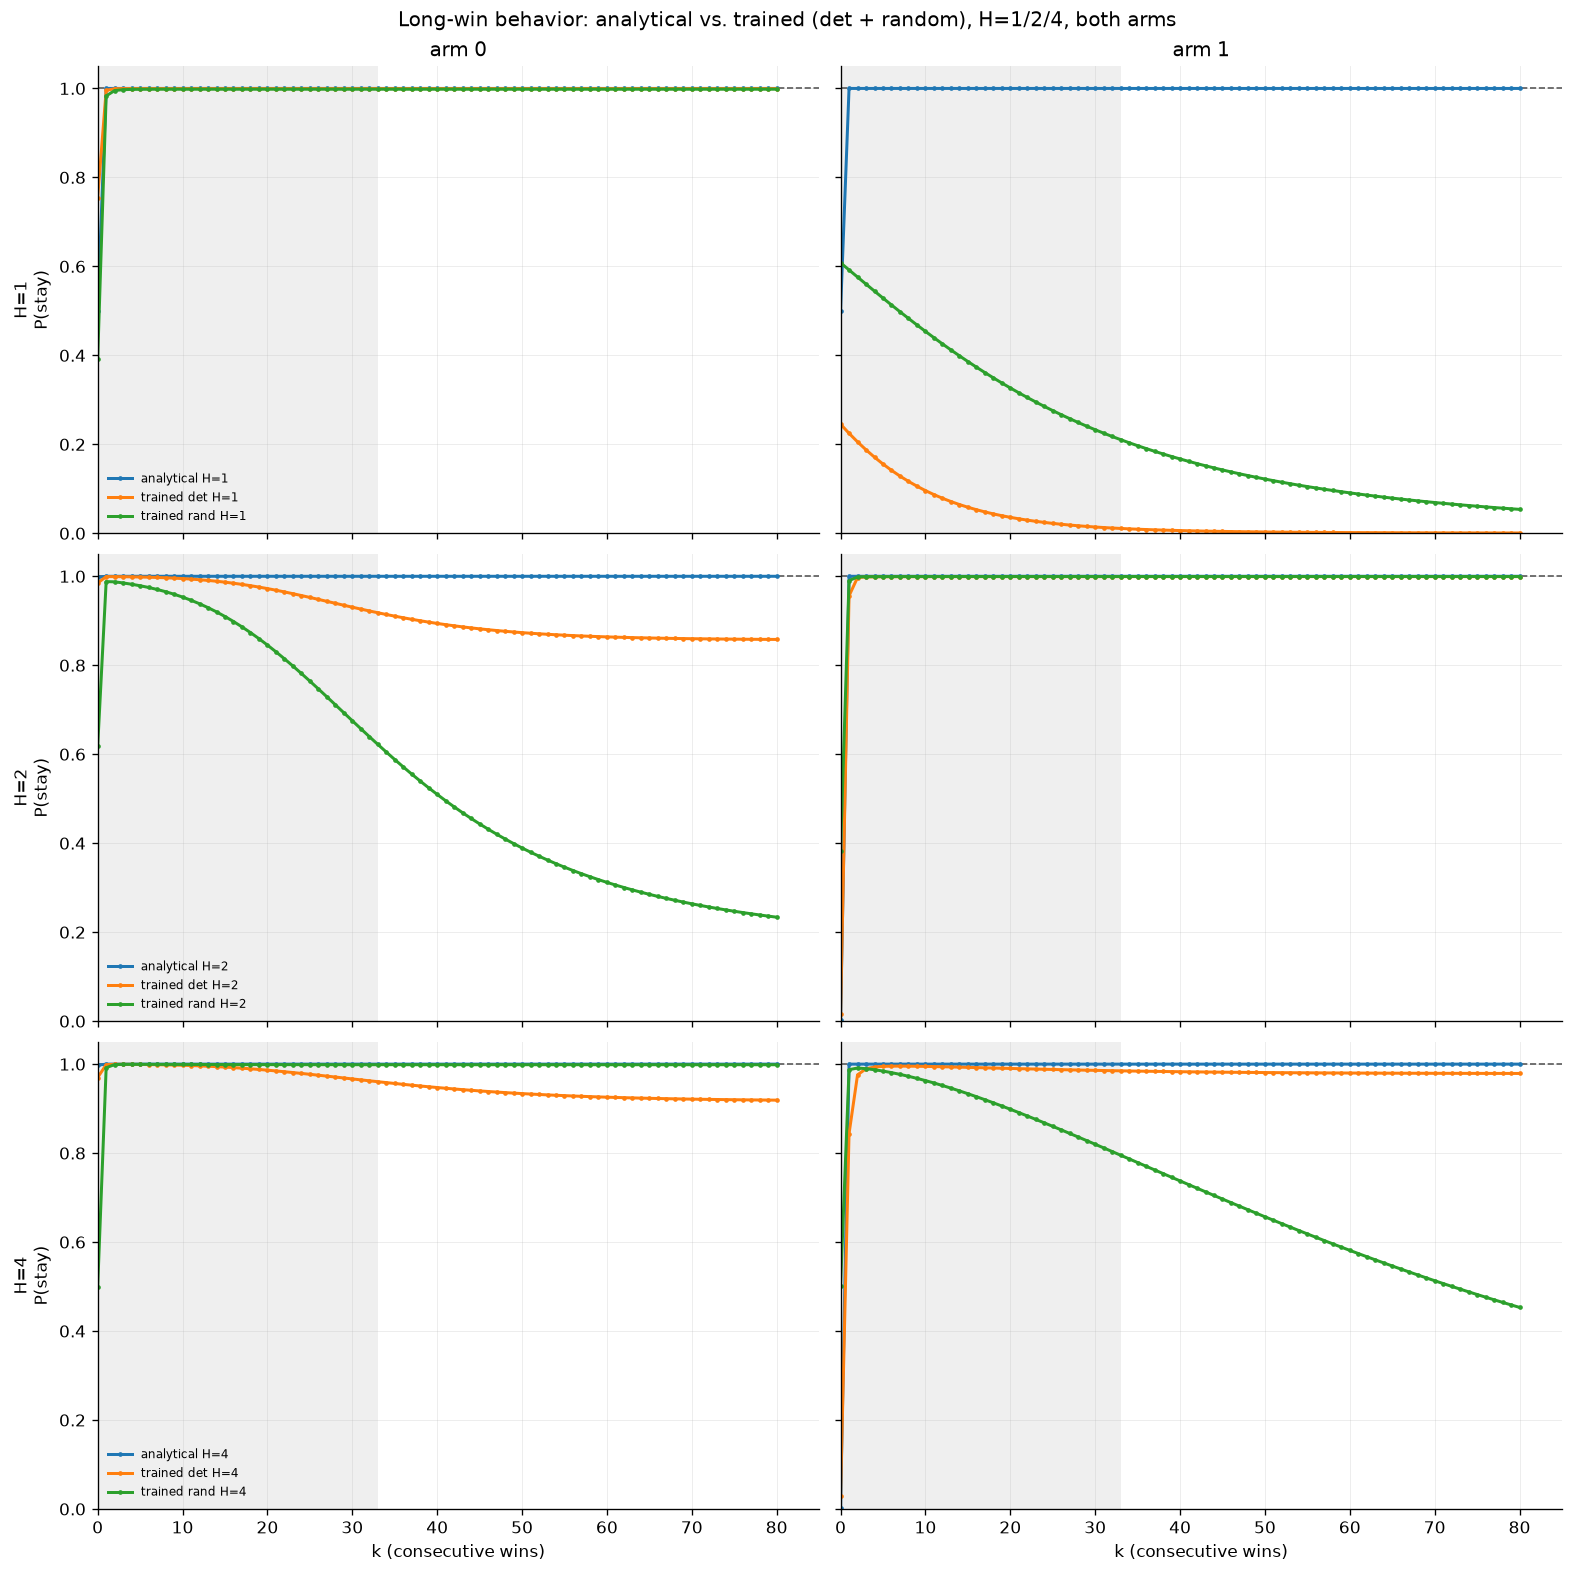

In [38]:
# --- 17.5 -- long-win behavior: paired action panels, H=1/H=2/H=4, analytical vs. both trained -
# Both arms shown (not just arm 0) -- §10.4/§10.5/§10.6 already established that trained-model
# failure can be action-asymmetric, so a single-arm plot would risk hiding it again.
fig, axes = plt.subplots(3, 2, figsize=(13, 13), sharex=True, sharey=True, constrained_layout=True)
for row, H in enumerate((1, 2, 4)):
    models_this_H = {
        f"analytical H={H}": ANALYTICAL_BY_H[H],
        f"trained det H={H}": TRAINED[(H, "det_init")],
        f"trained rand H={H}": TRAINED[(H, "random_init")],
    }
    for col, arm in enumerate((0, 1)):
        ax = axes[row, col]
        shade_indata(ax, d_det["max_streak"], label=False)
        ax.axhline(1.0, color=C_RULE, ls="--", lw=1.0)
        for label, P in models_this_H.items():
            probe = rnn_probe(P, arm, wi14, 2, 2, kmax=KMAX)
            ax.plot(KGRID, probe["pstay"], lw=1.8, marker="o", ms=1.8, label=label)
        ax.set_xlim(0, KMAX + 5); ax.set_ylim(0, 1.05)
        if row == 0:
            ax.set_title(f"arm {arm}")
        if row == 2:
            ax.set_xlabel("k (consecutive wins)")
    axes[row, 0].set_ylabel(f"H={H}\nP(stay)")
    axes[row, 0].legend(fontsize=7, loc="lower left")
fig.suptitle("Long-win behavior: analytical vs. trained (det + random), H=1/2/4, both arms")
plt.show()

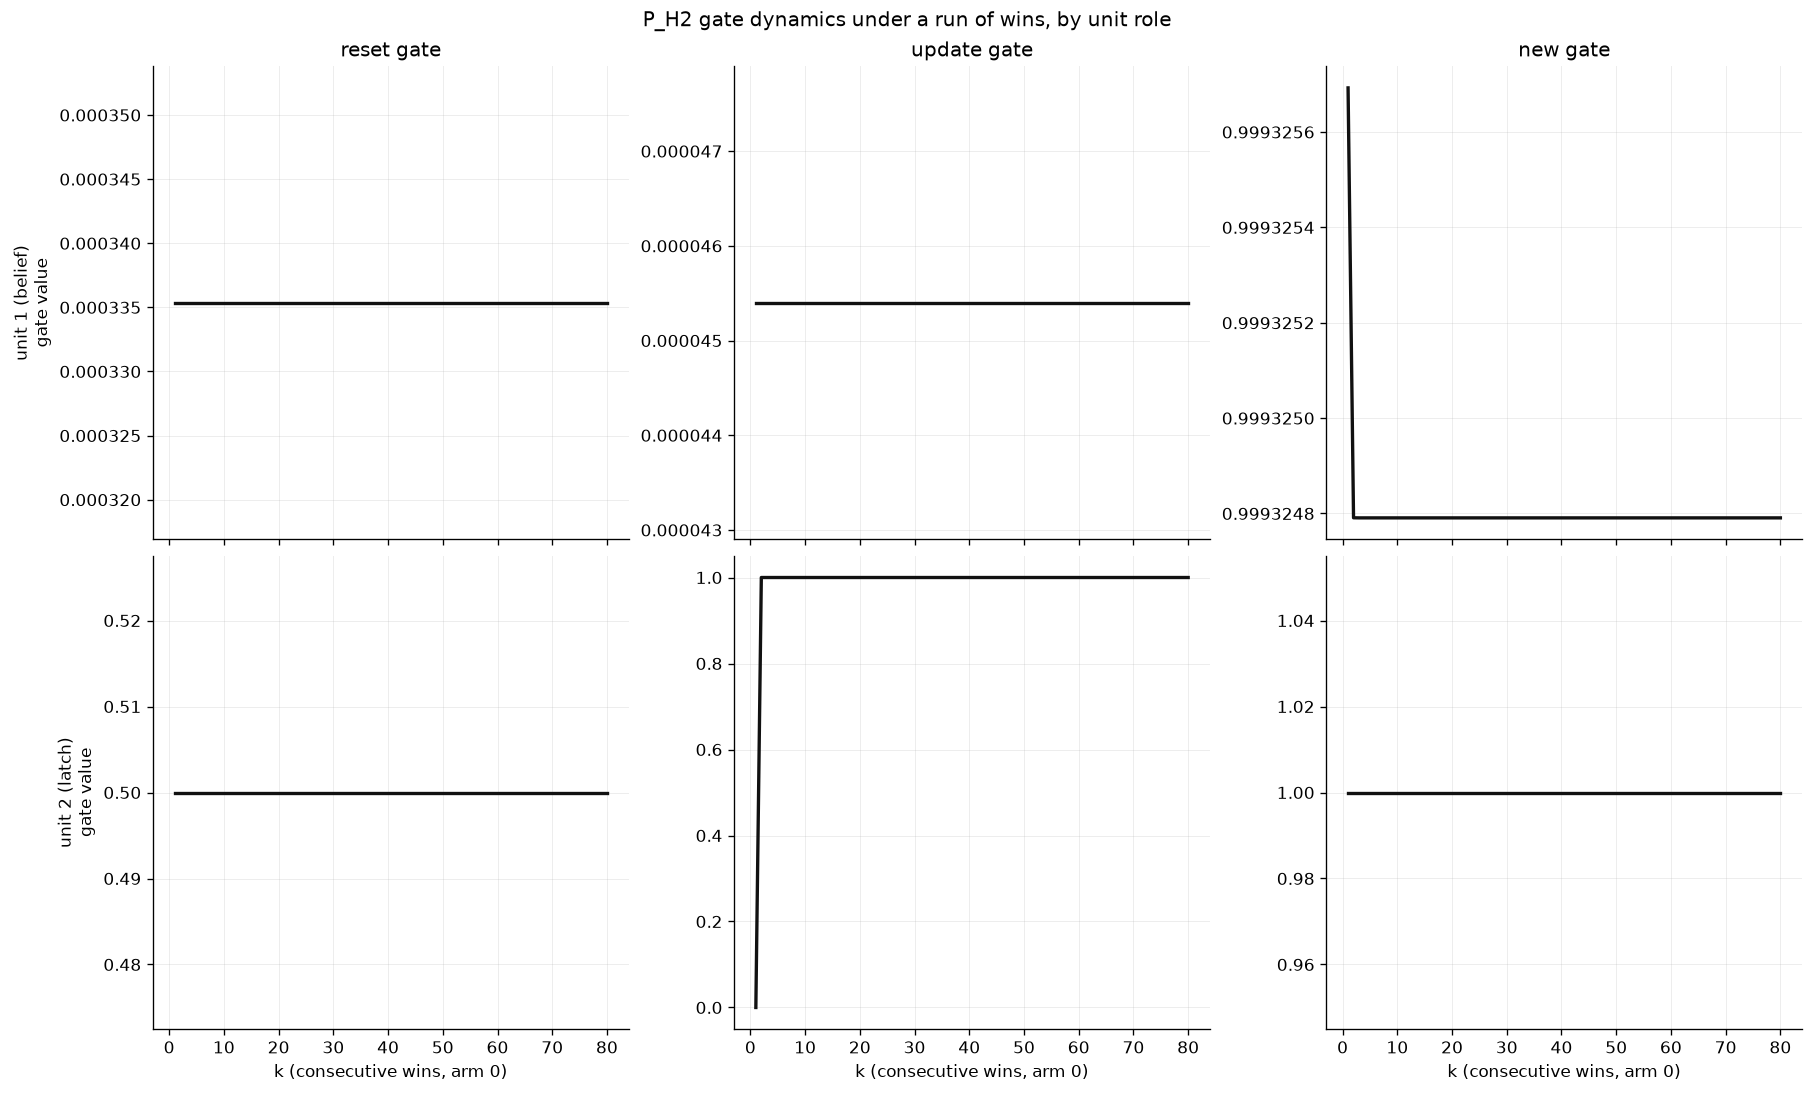

P_H4's units 1-2 numerically identical to P_H2 (arm 0, run of wins): True
P_H4's units 3-4 max |deviation from 0| across the whole run: 0.00e+00


In [39]:
# --- 17.6 -- gate traces for P_H2, labeled by unit role; numerical check that P_H4's active -----
# units match P_H2 and its dead units stay at zero (rather than re-plotting the same curves) ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, constrained_layout=True)
unit_roles = {0: "unit 1 (belief)", 1: "unit 2 (latch)"}
probe_h2_arm0 = rnn_probe(P_H2, 0, wi14, 2, 2, kmax=KMAX)
for row in (0, 1):
    for col, gname in enumerate(("reset", "update", "new")):
        ax = axes[row, col]
        vals = [g[gname][row] for g in probe_h2_arm0["gates"]]
        ax.plot(KGRID[1:], vals, lw=2.0, color="#111111")
        ax.ticklabel_format(useOffset=False, style="plain", axis="y")
        if row == 0:
            ax.set_title(f"{gname} gate")
        if row == 1:
            ax.set_xlabel("k (consecutive wins, arm 0)")
    axes[row, 0].set_ylabel(f"{unit_roles[row]}\ngate value")
fig.suptitle("P_H2 gate dynamics under a run of wins, by unit role")
plt.show()

probe_h4_arm0 = rnn_probe(P_H4, 0, wi14, 2, 2, kmax=KMAX)
active_match = np.allclose(probe_h2_arm0["hidden"], probe_h4_arm0["hidden"][:, :2], atol=1e-9)
dead_zero_max = float(np.abs(probe_h4_arm0["hidden"][:, 2:]).max())
print(f"P_H4's units 1-2 numerically identical to P_H2 (arm 0, run of wins): {active_match}")
print(f"P_H4's units 3-4 max |deviation from 0| across the whole run: {dead_zero_max:.2e}")

In [40]:
# --- 17.7 -- stability summary (win fixed point + loss two-step), all rows ---------------------
print(f"{'model':<26} {'fp0 P(stay)':>11} {'fp1 P(stay)':>11} {'win eig (arm0)':>20} "
      f"{'loss orbit\nalternates':>14} {'loss 2-step eig':>22} {'loss spec radius':>16}")
for label, r in ROWS.items():
    print(f"{label:<26} {r['fp0_pstay']:>11.4f} {r['fp1_pstay']:>11.4f} "
          f"{np.round(r['win_eig0'], 4)!s:>20} {str(r['loss_orbit_alternates']):>14} "
          f"{np.round(r['loss_eig'], 4)!s:>22} {r['loss_spec_radius']:>16.4f}")

model                      fp0 P(stay) fp1 P(stay)       win eig (arm0) loss orbit
alternates        loss 2-step eig loss spec radius
analytical H=1                  1.0000      1.0000                 [0.]           True                   [0.]           0.0000
embedded H1 in H2               1.0000      1.0000              [0. 0.]           True                [0. 0.]           0.0000
genuine analytical H=2          1.0000      1.0000              [0. 1.]           True                [0. 1.]           1.0000
embedded H2 in H4               1.0000      1.0000        [0. 1. 0. 0.]           True          [0. 1. 0. 0.]           1.0000
trained det H=1                 0.9996      0.0002             [0.1669]           True              [-0.0013]           0.0013
trained rand H=1                0.9983      0.0016             [0.4924]           True               [0.0002]           0.0002
trained det H=2                 0.8569      0.9992      [0.0771 0.9128]           True [ 1.444e-01 -1.00

## 18. Summary table

One consolidated table, all rows pulled directly from §17.1's `ROWS` dictionary -- nothing
recomputed, so this cannot drift out of sync with §17's individual tables.

In [41]:
# --- 18.1 -- consolidated summary table ---------------------------------------------------------
summary_rows = []
for label, r in ROWS.items():
    summary_rows.append({
        "model": label,
        "nominal H": r["H"],
        "active units": r["active_units"] if r["active_units"] is not None else "N/A",
        "P(a0) t=0": round(r["first_action_p_a0"], 4),
        "1st-win pass": r["first_win_pass"],
        "1st-loss pass": r["first_loss_pass"],
        "steady (of 4)": r["steady_pass"],
        "full CE": round(r["full_ce"], 4),
        "CE excl init": round(r["ce_excl_init"], 4),
        "init-only CE": round(r["init_only_ce"], 4),
        "fp P(stay) arm0": round(r["fp0_pstay"], 4),
        "fp P(stay) arm1": round(r["fp1_pstay"], 4),
        "win eig (arm0)": np.round(r["win_eig0"], 4).tolist(),
        "loss 2-step eig": np.round(r["loss_eig"], 4).tolist(),
        "raw L1 norm": round(r["l1_norm"], 3),
        "verified reg. penalty": ("N/A" if r["is_analytical"] else round(1e-5 * r["l1_norm"], 6)),
    })
summary_df = pd.DataFrame(summary_rows)
summary_df

,model,nominal H,active units,P(a0) t=0,1st-win pass,1st-loss pass,steady (of 4),full CE,CE excl init,init-only CE,fp P(stay) arm0,fp P(stay) arm1,win eig (arm0),loss 2-step eig,raw L1 norm,verified reg. penalty
0,analytical H=1,1,1,0.5000,True,False,4,0.0855,0.0825,0.6931,1.0000,1.0000,[0.0],[0.0],34.000,N/A
1,embedded H1 in H2,2,1,0.5000,True,False,4,0.0855,0.0825,0.6931,1.0000,1.0000,"[0.0, 0.0]","[0.0, 0.0]",34.000,N/A
2,genuine analytical H=2,2,2,0.9975,True,True,4,0.0000,0.0000,0.0025,1.0000,1.0000,"[0.0, 1.0]","[0.0, 1.0]",72.000,N/A
3,embedded H2 in H4,4,2,0.9975,True,True,4,0.0000,0.0000,0.0025,1.0000,1.0000,"[0.0, 1.0, 0.0, 0.0]","[0.0, 1.0, 0.0, 0.0]",72.000,N/A
4,trained det H=1,1,N/A,0.7547,True,True,3,0.0034,0.0020,0.2814,0.9996,0.0002,[0.1669],[-0.0013],26.350,0.000263
5,trained rand H=1,1,N/A,0.3919,True,True,3,0.0067,0.0020,0.9368,0.9983,0.0016,[0.4924],[0.0002],26.819,0.000268
6,trained det H=2,2,N/A,0.9848,True,True,4,0.0010,0.0010,0.0153,0.8569,0.9992,"[0.0771, 0.9128]","[0.1444, -0.0001]",42.733,0.000427
7,trained rand H=2,2,N/A,0.6177,True,True,3,0.0033,0.0009,0.4818,0.1778,0.9995,"[0.0415, 0.9617]","[0.0442, 0.001]",44.687,0.000447
8,trained det H=4,4,N/A,0.9698,True,True,4,0.0003,0.0001,0.0306,0.9167,0.9786,"[0.0524, 0.3399, 0.9331, 0.9339]","[(-0.0425+0j), (0.0007+0.0015j), (0.0007-0.001...",72.066,0.000721
9,trained rand H=4,4,N/A,0.4990,True,True,3,0.0036,0.0002,0.6952,0.9987,0.1186,"[(0.8769+0j), (0.042+0j), (0.5356+0.0025j), (0...","[0.0998, -0.0287, -0.0003, 0.0025]",78.064,0.000781


## 19. Discussion (H=2 and H=4)

**H=1** (§8-11, recap). Tests whether one unit can represent stable steady-state WSLS. It
succeeds once past initialization (§14's four steady-state cases all pass), but keeps two known
limitations by construction: the first action is 50/50, and it fails to shift after a first-trial
loss (§9, §14.3).

**H=2.** Tests whether a *distinct initialization mechanism* -- not more capacity applied to the
same mechanism -- can remove H=1's startup limitations while leaving everything else alone. §14
checked this directly: `P_H2` gives a deterministic first action (§14.2), passes both first-win
and first-loss (§14.3, where `P_H1` and `P_H2_embed` fail first-loss), passes all four ordinary
steady-state transitions (§14.4), and its loss-driven orbit alternates arms correctly (§16). §17.2b
checked whether this also removes H=1's CE concentration in sessions that open with a loss (traced
precisely in this conversation before this task began) -- and it does, completely: every one of
`P_H2`'s four (previous outcome x transition-position) buckets comes back at numerically
negligible CE, where `P_H1` showed 19.99 nats on the first-loss bucket and 0.0785 nats averaged
over the later-loss bucket (`P_H1`'s corrupted-then-flips-again pattern from a wrong-signed
first-loss belief, described earlier in this conversation). This is not assumed to transfer from
the behavioral-correctness result -- CE also reflects confidence, not just direction -- it is
checked directly, and it holds. The unavoidable
symmetry tension from §13 (a constant bias that fixes initialization is still present, in a
smaller way, at every later step) is a known, explicit property of this construction, not an
oversight.

**Embedded H1 in H2 (`P_H2_embed`).** A capacity control: §14 confirms it reproduces every one of
H=1's results (including H=1's specific first-loss failure) at nominal `H=2`, because its second
unit never does anything (§15's near-zero eigenvalue for that unit, §17.6-style zero-deviation
checks in spirit). This demonstrates directly that a bigger hidden layer does nothing on its own
when the extra capacity goes unused -- the fix in `P_H2` came from a *different mechanism*
occupying the second unit, not from the unit merely existing.

**H=4.** Tests whether unused nominal capacity changes anything once the two-unit mechanism is
already available. §15 and §17.6 check numerically whether `P_H4`'s active units (1-2) match
`P_H2` and whether its inactive units (3-4) stay at zero -- if that holds, `P_H4` is exactly the
control result it was built to be. **Do not read `P_H4` as "H=4 performs better than H=2"** if the
two are numerically identical in every reported quantity; that identity is the intended finding,
not a null result to explain away.

**What this does and does not establish.** A successful analytical construction at a given `H`
shows that architecture can represent the target behavior under the tested assumptions -- it says
nothing on its own about whether gradient descent, from a generic initialization, optimizing a
behavioral loss plus L1, reliably *finds* that representation. §17's matched comparisons (CE,
parameter norms, fixed points, gate traces, long-win curves) are what let capacity, optimization,
regularization, and initialization be examined as separate factors instead of one bundled claim,
exactly as in §11's discussion for H=1. If a trained model at a given `H` fails where its matched
analytical construction succeeds, that is evidence consistent with an optimization-, regularization-,
initialization-, or finite-data-related explanation for the trained model's failure -- not proof
that any one of those is *the* cause, and not evidence about what happens at hidden sizes or tasks
outside what was actually tested here.

**Explicitly, for the record:**
- `P_H4` is an embedded-H2 capacity control, not a new four-unit strategy.
- No genuinely four-dimensional (four *active* units) analytical mechanism was built here -- doing
  so would answer a different question (whether a fourth active computational role helps), out of
  scope for this benchmark.
- None of `P_H1`, `P_H2_embed`, `P_H2`, or `P_H4` were obtained by minimizing any training
  objective. All four are sufficient-condition constructions, not optimal ones, chosen from
  underdetermined families of weights that would satisfy the same target behaviors.